# Reproducing Feature-Effect Geometry Analysis with **Murano**

> *Sparse Autoencoders Encode Both Concepts and Functions: The Downstream Geometry of Feature Effects.* Phu Gia Hoang, Anwoy Chatterjee, Tanmoy Chakraborty, Iryna Gurevych, Subhabrata Dutta. 2026. [arXiv:2607.24645](https://arxiv.org/abs/2607.24645) · [FEGA project](https://ukplab.github.io/FEGA/)

SAE features are commonly interpreted by looking at the text that activates them. FEGA asks a complementary question: when an active feature is removed, does it change the model’s predictions in the same way across different prompts?

For one prompt, FEGA runs the model twice at a chosen token. The first run replaces the model activation with its complete SAE reconstruction. The second uses the same reconstruction after setting one SAE feature to zero. Subtracting the two final activations gives the effect of removing that feature. Through the model’s unembedding matrix, this effect describes which vocabulary logits increase and which decrease.

Repeating the intervention across prompts produces one effect vector per prompt. If these vectors point in nearly the same direction, the feature has a consistent effect. If they form several directions or occupy a low-dimensional region, the feature has structured but context-dependent effects. If they scatter broadly, the feature’s effect changes substantially with context.

**What you will learn.**
1. Use Murano to encode and decode an SAE activation, remove one feature, and measure the resulting model change.
2. Understand how FEGA turns effects from many prompts into a geometric dataset.
3. Compute directional, dimensional, and clustering measurements for that dataset.
4. Recover the eight geometry families used by FEGA.
5. Compare the resulting labels, 3D sphere plots, and 2D projections with the original implementation.

**The task.** 

The live example removes one Gemma 2 SAE feature across 64 prompts. This demonstrates how Murano produces the effects that FEGA analyzes.

The original paper experimented with many models, SAEs, and features, which is too expensive for a repository notebook. To exercise every geometry family, this notebook includes eight small matrices exported from the original FEGA experiments. Each matrix belongs to one SAE feature: its rows correspond to prompts, and each row contains the model change caused by removing that feature. This notebook then recomputes the geometry measurements, clustering, stability result, label, and plots from these matrices.

**On fidelity.** 

This notebook runs one feature intervention from prompts through the model and reproduces the complete geometry analysis for eight original FEGA examples. It does not repeat the paper’s model-wide feature search or aggregate experiments. Those omitted stages choose which features to study; they do not replace the geometry calculations reproduced here.

**The result you will find.** 

The eight examples recover the original FEGA geometry labels. Their newly generated 3D sphere and 2D projection plots show the same directional, clustered, or diffuse structures as the corresponding original paper's figures. The live Gemma example shows how the required effects can be collected with Murano.


## 1. Data

FEGA studies one SAE feature across many prompts. For each prompt, the feature is removed at a selected token and the resulting change in the model is recorded as a vector. Stacking these vectors produces an **effect matrix**: rows correspond to prompts, while columns correspond to model dimensions. The following sections determine whether its rows share one direction, form several groups, occupy a low-dimensional region, or vary diffusely.

This reproduction uses two sets of data:

- **Live Gemma example.** `artifacts/inputs.json` contains 64 ordered prompts, their target token positions, and the selected feature ID (`33760`). These are ordinary model inputs. In Section 4, Murano runs the SAE intervention and computes one effect vector for every prompt.

- **Eight examples from the original FEGA experiments.** `artifacts/effect_clouds.npz` contains eight effect matrices, one representing each FEGA geometry family. Together they contain 361 prompt-level effects. Here, the directional measurements, clustering, stability checks, geometry labels, and plots will be recomputed from those matrices.

The original paper obtained these matrices by running large model and SAE experiments. Including only the resulting effect matrices keeps this reproduction small while preserving the complete geometry analysis that begins after feature effects have been collected.

The original FEGA measurements, labels, and figures are stored separately. They are used only in the comparison section, after the new results have been computed, so readers can see whether the same effect matrices lead to the same numerical conclusions and visual structures.

## 2. Method

An SAE feature can activate on similar text while producing different consequences for the model. FEGA therefore studies what happens when the feature is removed, rather than relying only on its activation pattern.

The analysis follows five steps:

1. **Remove one feature while keeping the remaining SAE reconstruction fixed.** For a selected prompt and token, the baseline run replaces the model activation with the complete SAE reconstruction. A second run uses the same reconstruction after setting one feature activation to zero. This isolates the contribution of that feature without changing the other active features.

2. **Measure the resulting output change.** FEGA subtracts the final hidden vectors from the two runs and evaluates the difference through the model’s unembedding. The resulting effect describes which vocabulary logits are raised or lowered when the feature is removed.

3. **Repeat the intervention across prompts.** Each prompt produces one effect vector. Comparing their directions reveals whether the feature produces the same output change across contexts or behaves differently depending on the prompt.

4. **Measure the shape of the effects.** FEGA checks how strongly the vectors align and how many dimensions are needed to describe them. When the effects do not share one direction, a spherical clustering model tests whether they form a small number of recurring directions instead.

5. **Assign and inspect the geometry.** The measurements and stability checks determine the geometry family. A 3D unit-sphere view shows how the effect directions are distributed, while a 2D projection makes clusters and overlaps easier to inspect.


**Murano's role.**

Here, Murano performs the model and SAE operations for one Gemma feature: loading the prompts, reconstructing the selected activation, removing the feature, and collecting the resulting effects. The same geometry analysis is then applied to the eight original FEGA effect matrices described in Section 1.

For reproducibility, the Gemma example uses the same ordered 64 prompts and a fixed batch size of eight throughout effect collection. Its result describes that specific worked example. The eight original effect matrices provide the examples used to reproduce and compare all geometry families.

## 3. Setup

The live example uses `google/gemma-2-2b` and an SAE trained on its residual stream after layer 12. The intervention must occur at the same layer on which the SAE was trained; otherwise its encoded features and decoded reconstructions would not describe the activation being replaced.

Murano loads the language model, identifies the target layer, and exposes the model’s unembedding matrix. The SAE wrapper provides both encoding and decoding, which allows the full reconstruction and the feature-removed reconstruction to be created from the same activation.

A CUDA GPU is required for the live model run. The first execution also needs access to Hugging Face to download the Gemma checkpoint and SAE weights. Run from the Murano repository root so the local FEGA code and files under `notebooks/reproductions/fega/artifacts/` resolve correctly.

Here, the model settings, feature ID, prompt order, batch size, and random seeds are defined once and reused throughout the remaining sections. Keeping these values fixed makes the intervention, directional clustering, and visualizations repeatable when the same software and hardware are used.

In [ ]:
from __future__ import annotations

import json
import sys
import tempfile
from pathlib import Path

import numpy as np
import torch
from IPython.display import Markdown, display

START_DIRECTORY = Path.cwd().resolve()
REPO_ROOT = next(
    (
        directory
        for directory in (START_DIRECTORY, *START_DIRECTORY.parents)
        if (directory / "pyproject.toml").is_file()
        and (directory / "notebooks" / "reproductions" / "fega").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from a cloned Murano repository")
sys.path.insert(0, str(REPO_ROOT))

from murano import PromptBatch, keys as murano_keys  # noqa: E402
from murano.model import MuranoModel  # noqa: E402
from murano.results import Results  # noqa: E402
from notebooks.reproductions.fega.fega_method import (  # noqa: E402
    DictionarySAEModel,
    FEGAComputeEffect,
    FEGAConfig,
    FEGADataPrep,
    FEGAGeometryMetrics,
    FEGAGeometryReporting,
    FEGAStability,
    FEGAVisualize,
    FEGAVMF,
    keys as fega_keys,
)
from notebooks.reproductions.fega.fega_method.artifacts import (  # noqa: E402
    FEGACuratedFeatureInput,
    FEGAEffectStore,
    build_effect_store_from_raw_cloud,
)
from notebooks.reproductions.fega.fega_method.contexts import prepare_contexts  # noqa: E402

BUNDLE_ROOT = REPO_ROOT / "notebooks" / "reproductions" / "fega"
ARTIFACT_ROOT = BUNDLE_ROOT / "artifacts"
if not ARTIFACT_ROOT.is_dir():
    raise FileNotFoundError("FEGA artifacts are missing")

In [2]:
def run_downstream(effect_store: FEGAEffectStore, output_dir: str) -> Results:
    """Analyze and visualize an already collected set of FEGA effects.

    This function starts after the model interventions have produced one effect
    vector per prompt. It measures the shape of those vectors, looks for
    recurring directions, checks whether the result is stable, assigns each
    feature a geometry label, and generates the corresponding figures.

    Args:
        effect_store: Prompt-level feature effects together with the unembedding
            geometry used to compare their consequences for vocabulary logits.
        output_dir: Directory in which the 3D sphere and 2D projection figures
            will be written.

    Returns:
        A Murano ``Results`` object containing the intermediate measurements,
        fitted directional models, stability results, geometry labels, and
        generated-figure metadata.
    """
    results = Results()
    results[fega_keys.EFFECTS] = effect_store
    config = FEGAConfig()

    # Run the analysis in order:
    #   1. measure alignment and dimensionality;
    #   2. fit spherical mixtures when several directions may be present;
    #   3. check whether the inferred structure is stable;
    #   4. convert the measurements into a geometry family;
    #   5. draw one representative 3D and 2D view for each family.
    for step in (
        FEGAGeometryMetrics(config),
        FEGAVMF(model, config, n_jobs=1),
        FEGAStability(config),
        FEGAGeometryReporting(),
        FEGAVisualize(
            output_dir,
            top_k_per_family=1,
            figures=("sphere_surface", "projection_2d"),
            dpi=180,
        ),
    ):
        step(results)

    return results


def markdown_table(headers: tuple[str, ...], rows: list[tuple[object, ...]]) -> str:
    """Format a small result table for display in a Markdown cell.

    The helper keeps tabular output readable without adding a dataframe
    dependency or allowing display formatting to affect the numerical results.

    Args:
        headers: Column names in display order.
        rows: Values to display, with one tuple per table row.

    Returns:
        A GitHub-flavored Markdown table as a single string.
    """
    # Markdown tables consist of a header, a required divider, and one formatted
    # line per result row. Values are converted to strings only for display.
    header_line = "| " + " | ".join(headers) + " |"
    divider_line = "| " + " | ".join("---" for _ in headers) + " |"
    body_lines = ["| " + " | ".join(str(value) for value in row) + " |" for row in rows]
    return "\n".join((header_line, divider_line, *body_lines))

In [3]:
MODEL_ID = "google/gemma-2-2b"
SAE_REPO = "canrager/saebench_gemma-2-2b_width-2pow16_date-0107"
SAE_ID = "gemma-2-2b_standard_new_width-2pow16_date-0107/resid_post_layer_12/trainer_2"

# Run feature 33760 on the 64 prompts included with this example.
FEATURE_ID = 33760
LIVE_BATCH_SIZE = 8
PRESELECTED_ROWS = tuple(range(64))

# Reproduce the eight original FEGA examples in this display order.
EXPECTED_FEATURE_ORDER = (33760, 14513, 54361, 32542, 59154, 19224, 34636, 1425)

# Allow normal float32 rounding in numerical and visual comparisons.
GEOMETRY_TOLERANCE = {"rtol": 1.0e-6, "atol": 1.0e-8}
RENDERER_INVARIANT_TOLERANCE = {"rtol": 1.0e-6, "atol": 1.0e-6}

# Load the feature descriptions and prompt records.
inputs_payload = json.loads((ARTIFACT_ROOT / "inputs.json").read_text())
feature_inputs = tuple(
    FEGACuratedFeatureInput.from_mapping(item) for item in inputs_payload["features"]
)
feature_ids = tuple(feature.feature_id for feature in feature_inputs)


# Load the prompt-level effects and the row boundaries between features.
with np.load(ARTIFACT_ROOT / "effect_clouds.npz", allow_pickle=False) as archive:
    delta_rows = torch.from_numpy(np.array(archive["delta"], copy=True))
    row_offsets = tuple(int(value) for value in archive["row_offsets"].tolist())

# Select the prompts needed for the live intervention.
live_input = next(
    feature for feature in feature_inputs if feature.feature_id == FEATURE_ID
)
live_rows = live_input.rows

In [4]:
# Load Gemma with eager attention
model = MuranoModel(
    MODEL_ID,
    dtype=torch.bfloat16,
    attn_implementation="eager",
)

# Load the layer-12 SAE on the model's device and in the same dtype
sae = DictionarySAEModel(
    SAE_REPO,
    SAE_ID,
    MODEL_ID,
    device=str(model.unembed_weight.device),
    dtype=torch.bfloat16,
)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## 4. Collect feature effects with Murano

Before FEGA can study a feature’s geometry, it needs to measure that feature’s effect in several contexts. Here, feature `33760` is removed from the same 64 prompts included with this reproduction.

For each prompt, Murano locates the selected token and encodes its layer-12 activation with the SAE. The baseline run uses the complete SAE reconstruction. A second run decodes the same SAE activations after setting feature `33760` to zero. The difference between the two model outputs is the feature’s effect for that prompt.

Using the same encoded activation in both runs keeps every other SAE feature unchanged. This makes the measured difference specific to feature `33760`. The feature must also be active in the selected prompt; removing an inactive feature would produce no meaningful intervention. All 64 prompts used here have a positive activation.

The prompts are processed in batches of eight. This is a fixed runtime choice for repeating the example, not a parameter of the FEGA method.

All 64 interventions produce finite effect vectors. Most point in a common direction, so FEGA labels this example `directed_ray`. A multi-direction clustering model is therefore unnecessary. However, the stability check does not confirm the label, so this example demonstrates how Murano collects and analyzes feature effects without claiming that feature `33760` has the same geometry for every possible prompt set.

In [5]:
# Attach FEGA grouping labels to the 64 prompts used in the live run.
prompt_batch = PromptBatch(
    prompts=[str(row.prompt) for row in live_rows],
    source="fega-live-33760",
    metadata={
        "fega": {
            "attribute_label": [row.attribute_label for row in live_rows],
            "pair_role": [row.pair_role for row in live_rows],
            "pair_index": [row.pair_index for row in live_rows],
            "group_label": [row.stability_group for row in live_rows],
        }
    },
)
logical_targets = tuple(int(row.logical_target_position) for row in live_rows)

# Select feature 33760 at the stored target position in every prompt.
live_results = Results()
live_results[murano_keys.PROMPTS] = prompt_batch
FEGADataPrep(
    model,
    SAE_REPO,
    SAE_ID,
    [FEATURE_ID],
    position=logical_targets,
    batch_size=LIVE_BATCH_SIZE,
    activation_threshold=0.0,
    max_contexts=len(live_rows),
    sae_model=sae,
    preselected_context_indices={FEATURE_ID: PRESELECTED_ROWS},
)(live_results)

# Compare the full SAE reconstruction with the same reconstruction after zeroing the feature.
FEGAComputeEffect(model, batch_size=LIVE_BATCH_SIZE, sae_model=sae)(live_results)
live_store = live_results[fega_keys.EFFECTS]
live_feature = live_store.features[FEATURE_ID]

# Confirm that every prompt produced a positive, finite feature effect.
assert len(live_feature.directions) == len(live_rows)
assert all(live_feature.retained_mask)
assert bool(torch.isfinite(live_feature.feature_activations).all().item())
assert bool(torch.all(live_feature.feature_activations > 0.0).item())
assert bool(torch.isfinite(live_feature.directions).all().item())
assert bool(torch.isfinite(live_feature.magnitudes).all().item())

# Confirm that tokenization and target positions match the included prompt records.
assert all(
    context.input_ids == tuple(row.source_token_ids)
    and context.target_position == row.logical_target_position
    for row, context in zip(live_rows, live_feature.contexts, strict=True)
)

# Show the prompts and target positions used for the intervention.
live_identity_rows = [
    (
        row_index,
        row.source_context_index,
        row.attribute_label,
        row.logical_target_position,
        " ".join(str(token) for token in row.source_token_ids),
        row.prompt,
    )
    for row_index, row in enumerate(live_rows)
]
display(
    Markdown(
        "### Prompts used for feature 33760\n\n"
        + markdown_table(
            ("row", "context", "attribute", "target_pos", "token_ids", "prompt"),
            live_identity_rows,
        )
    )
)

/scratch/418004/ipykernel_767722/1504052635.py:19: RuntimeWarning: reduced-precision FEGA effect collection can be batch-sensitive; batch size is part of the result; float32 model weights reduced the observed sensitivity in the validated Gemma run
  FEGADataPrep(
/scratch/418004/ipykernel_767722/1504052635.py:33: RuntimeWarning: reduced-precision FEGA effect collection can be batch-sensitive; batch size is part of the result; float32 model weights reduced the observed sensitivity in the validated Gemma run
  FEGAComputeEffect(model, batch_size=LIVE_BATCH_SIZE, sae_model=sae)(live_results)


### Prompts used for feature 33760

| row | context | attribute | target_pos | token_ids | prompt |
| --- | --- | --- | --- | --- | --- |
| 0 | 1675 | Bulgaria | 4 | 2 8918 235292 11956 21262 235269 3170 235292 | city: Turnovo, country: |
| 1 | 2357 | Russia | 5 | 2 8918 235292 11734 785 19677 235269 3170 235292 | city: Voronezh, country: |
| 2 | 2133 | Mozambique | 4 | 2 8918 235292 10926 22883 235269 3170 235292 | city: Cuamba, country: |
| 3 | 2922 | Finland | 3 | 2 8918 235292 230633 235269 3170 235292 | city: Turku, country: |
| 4 | 1007 | Bulgaria | 4 | 2 8918 235292 36629 5445 235269 3170 235292 | city: Dobrich, country: |
| 5 | 3856 | Angola | 4 | 2 8918 235292 34154 6388 235269 3170 235292 | city: Lubango, country: |
| 6 | 4771 | India | 5 | 2 8918 235292 653 7665 2051 235269 3170 235292 | city: Gwalior, country: |
| 7 | 1124 | France | 4 | 2 8918 235292 8005 549 235269 3170 235292 | city: Melun, country: |
| 8 | 3403 | Angola | 5 | 2 8918 235292 6548 808 619 235269 3170 235292 | city: Menongue, country: |
| 9 | 812 | Finland | 3 | 2 8918 235292 189448 235269 3170 235292 | city: Tampere, country: |
| 10 | 1024 | Portugal | 5 | 2 8918 235292 5949 1091 3378 235269 3170 235292 | city: Portalegre, country: |
| 11 | 3764 | Poland | 3 | 2 8918 235292 201937 235269 3170 235292 | city: Lublin, country: |
| 12 | 471 | Angola | 4 | 2 8918 235292 45372 2355 235269 3170 235292 | city: Lobito, country: |
| 13 | 2053 | Uruguay | 3 | 2 8918 235292 119045 235269 3170 235292 | city: Montevideo, country: |
| 14 | 1418 | Ecuador | 3 | 2 8918 235292 98669 235269 3170 235292 | city: Quito, country: |
| 15 | 3023 | Germany | 3 | 2 8918 235292 40218 235269 3170 235292 | city: Munich, country: |
| 16 | 129 | Portugal | 3 | 2 8918 235292 136207 235269 3170 235292 | city: Braga, country: |
| 17 | 1479 | Serbia | 3 | 2 8918 235292 102505 235269 3170 235292 | city: Belgrade, country: |
| 18 | 1500 | Sweden | 3 | 2 8918 235292 41106 235269 3170 235292 | city: Stockholm, country: |
| 19 | 3428 | Russia | 4 | 2 8918 235292 584 598 235269 3170 235292 | city: Tver, country: |
| 20 | 3314 | Lithuania | 4 | 2 8918 235292 9830 37195 235269 3170 235292 | city: Kaunas, country: |
| 21 | 3435 | Finland | 4 | 2 8918 235292 21958 90348 235269 3170 235292 | city: Mikkeli, country: |
| 22 | 555 | Brazil | 5 | 2 8918 235292 2072 556 23823 235269 3170 235292 | city: Parnaiba, country: |
| 23 | 4864 | Portugal | 3 | 2 8918 235292 68696 235269 3170 235292 | city: Lisbon, country: |
| 24 | 398 | Russia | 4 | 2 8918 235292 29354 21262 235269 3170 235292 | city: Ivanovo, country: |
| 25 | 3925 | Sweden | 4 | 2 8918 235292 7294 1547 235269 3170 235292 | city: Visby, country: |
| 26 | 4404 | Russia | 5 | 2 8918 235292 6886 12841 1076 235269 3170 235292 | city: Balakovo, country: |
| 27 | 3288 | Switzerland | 3 | 2 8918 235292 13246 235269 3170 235292 | city: Bern, country: |
| 28 | 4306 | Russia | 4 | 2 8918 235292 57459 29015 235269 3170 235292 | city: Volkhov, country: |
| 29 | 3373 | Iran | 4 | 2 8918 235292 653 7879 235269 3170 235292 | city: Gorgan, country: |
| 30 | 1361 | Russia | 4 | 2 8918 235292 9627 26318 235269 3170 235292 | city: Saransk, country: |
| 31 | 2296 | Bulgaria | 5 | 2 8918 235292 596 13225 913 235269 3170 235292 | city: Plovdiv, country: |
| 32 | 2413 | Mozambique | 4 | 2 8918 235292 133851 2620 235269 3170 235292 | city: Nacala, country: |
| 33 | 595 | Hungary | 4 | 2 8918 235292 229985 3467 235269 3170 235292 | city: Debrecen, country: |
| 34 | 1964 | Germany | 3 | 2 8918 235292 117876 235269 3170 235292 | city: Augsburg, country: |
| 35 | 115 | Thailand | 4 | 2 8918 235292 30502 482 235269 3170 235292 | city: Chainat, country: |
| 36 | 1985 | Denmark | 4 | 2 8918 235292 687 55382 235269 3170 235292 | city: Odense, country: |
| 37 | 4383 | Cuba | 4 | 2 8918 235292 10269 104863 235269 3170 235292 | city: Holguin, country: |
| 38 | 1373 | Brazil | 4 | 2 8918 235292 46444 6715 235269 3170 235292 | city: Uberaba, country: |
| 39 | 3143 | Norway | 4 | 2 8918 235292 113741 631 235269 3170 235292 | city: Drammen, country: |
| 40 | 158 | Chile | 4 | 2 8918 235292 8326 13408 235269 3170 235292 | city: Osorno, country: |
| 41 | 454 | South Sudan | 4 | 2 8918 235292 713 11091 235269 3170 235292 | city: Juba, country: |
| 42 | 2316 | Ethiopia | 4 | 2 8918 235292 653 8263 235269 3170 235292 | city: Gonder, country: |
| 43 | 2716 | Nigeria | 4 | 2 8918 235292 2659 40145 235269 3170 235292 | city: Calabar, country: |
| 44 | 3581 | Norway | 4 | 2 8918 235292 200374 3132 235269 3170 235292 | city: Finnsnes, country: |
| 45 | 2756 | Ethiopia | 4 | 2 8918 235292 1842 46627 235269 3170 235292 | city: Mekele, country: |
| 46 | 2013 | Poland | 4 | 2 8918 235292 687 14918 235269 3170 235292 | city: Opole, country: |
| 47 | 15 | Brazil | 4 | 2 8918 235292 4155 126327 235269 3170 235292 | city: Brasilia, country: |
| 48 | 3824 | Ukraine | 4 | 2 8918 235292 73401 2423 235269 3170 235292 | city: Lutsk, country: |
| 49 | 4087 | Croatia | 4 | 2 8918 235292 11133 189634 235269 3170 235292 | city: Rijeka, country: |
| 50 | 4095 | Iran | 4 | 2 8918 235292 81920 9241 235269 3170 235292 | city: Mashhad, country: |
| 51 | 4324 | Russia | 4 | 2 8918 235292 747 208573 235269 3170 235292 | city: Kirov, country: |
| 52 | 853 | Canada | 3 | 2 8918 235292 71066 235269 3170 235292 | city: Edmonton, country: |
| 53 | 225 | Colombia | 5 | 2 8918 235292 584 6704 528 235269 3170 235292 | city: Tumaco, country: |
| 54 | 371 | Greece | 4 | 2 8918 235292 72306 2620 235269 3170 235292 | city: Kavala, country: |
| 55 | 930 | Russia | 4 | 2 8918 235292 18355 26318 235269 3170 235292 | city: Bryansk, country: |
| 56 | 2722 | Mexico | 3 | 2 8918 235292 139746 235269 3170 235292 | city: Monterrey, country: |
| 57 | 2687 | Argentina | 4 | 2 8918 235292 6828 96493 235269 3170 235292 | city: Catamarca, country: |
| 58 | 890 | Italy | 3 | 2 8918 235292 181292 235269 3170 235292 | city: Perugia, country: |
| 59 | 1821 | Brazil | 4 | 2 8918 235292 83760 32933 235269 3170 235292 | city: Paranagua, country: |
| 60 | 198 | Russia | 5 | 2 8918 235292 10855 11485 235257 235269 3170 235292 | city: Roslavl, country: |
| 61 | 324 | Angola | 4 | 2 8918 235292 23677 17317 235269 3170 235292 | city: Benguela, country: |
| 62 | 703 | Italy | 4 | 2 8918 235292 26432 13408 235269 3170 235292 | city: Livorno, country: |
| 63 | 1514 | Brazil | 4 | 2 8918 235292 2742 198981 235269 3170 235292 | city: Goiania, country: |

In [6]:
# Analyze this feature alone and write its figures to a temporary directory.
live_dir = tempfile.TemporaryDirectory(prefix="fega-live-derived-")
live_single_store = FEGAEffectStore(
    features={FEATURE_ID: live_feature},
    gram=live_store.gram,
    feature_ids=(FEATURE_ID,),
    metadata=dict(live_store.metadata),
)
live_downstream = run_downstream(live_single_store, live_dir.name)
live_reporting = live_downstream[fega_keys.REPORTING].features[FEATURE_ID]
live_geometry = live_downstream[fega_keys.GEOMETRY].features[FEATURE_ID]
live_capture = live_downstream[fega_keys.VISUALIZATION].captures[FEATURE_ID]

# Report the result and the settings required to repeat it.
live_provenance = live_downstream[fega_keys.EFFECTS].metadata["provenance"]
live_fega_config = json.dumps(
    live_downstream[fega_keys.VMF].fega_config,
    indent=2,
    sort_keys=True,
)
display(
    Markdown(
        f"""### Live example result

        - Model / SAE: `{MODEL_ID}` / `{SAE_ID}`
        - Gram dtype/shape/device: `{live_store.gram.dtype}` / `{tuple(live_store.gram.shape)}` / `{live_provenance["gram_compute_device"]}`
        - Readout: `{live_provenance["gram_readout"]}`
        - Batch size: `{live_provenance["data_prep_batch_size"]}`
        - Retained prompts: `{live_geometry.n_valid}` of `{len(live_rows)}`
        - Geometry: `{live_reporting.primary_label}`
        - Selected directions: `{live_reporting.selected_k}`
        - Confidence: `{live_reporting.confidence}`
        - Stability: `{live_reporting.stability_status}`

        FEGA settings:
        ```json
        {live_fega_config}
        ```
        """
            )
        )

### Live example result

        - Model / SAE: `google/gemma-2-2b` / `gemma-2-2b_standard_new_width-2pow16_date-0107/resid_post_layer_12/trainer_2`
        - Gram dtype/shape/device: `torch.float64` / `(2304, 2304)` / `cuda:0`
        - Readout: `final_residual_output_embedding`
        - Batch size: `8`
        - Retained prompts: `64` of `64`
        - Geometry: `directed_ray`
        - Selected directions: `None`
        - Confidence: `unstable`
        - Stability: `unstable`

        FEGA settings:
        ```json
        {
  "bootstrap_rounds": 200,
  "ci_quantiles": [
    0.025,
    0.975
  ],
  "eps": 1e-12,
  "max_enumerated_subsets": 20,
  "min_contexts": 8,
  "min_group_count": 2,
  "min_group_size": 2,
  "residual_k_values": [
    1,
    2,
    3,
    4
  ],
  "sample_size_rounds": 20,
  "sample_sizes": [
    8,
    16,
    32,
    64,
    128,
    256
  ],
  "seed": 42,
  "span_k_values": [
    1,
    2,
    3,
    4,
    8
  ],
  "strong_sample_size_rounds": 50,
  "subspace_angle_quantile": 0.9,
  "subspace_eig_floor": 1e-08,
  "subspace_resample_fraction": 0.75,
  "subspace_resample_rounds": 20,
  "vmf_bic_tolerance": 1e-09,
  "vmf_k_values": [
    1,
    2,
    3,
    4
  ],
  "vmf_max_iter": 200,
  "vmf_n_init": 4,
  "vmf_resample_fraction": 0.8,
  "vmf_resample_rounds": 8,
  "warn_contexts": 64
}
        ```
        

## 5. Recover the eight FEGA geometry families

The live example showed how Murano produces one effect vector for each prompt. We now ask whether the same geometry analysis can recover the different kinds of feature behavior reported by FEGA, rather than only the `directed_ray` found for feature `33760`.

Here, eight effect matrices from the original FEGA experiments provide one example of each geometry family. The examples were selected to cover all eight families, but their expected labels are not given to the analysis. Every feature is processed with the same FEGA settings.

For each feature, FEGA first measures whether its effects share a common direction and how many dimensions they occupy. If one direction is insufficient, it tests whether the effects form several recurring directions. The stability check then determines whether that structure is reliable enough to report, and the resulting measurements produce the geometry label.

These effects were generated with the same Gemma model, so their directions are compared using its unembedding matrix. This makes two effects similar when they raise and lower similar vocabulary logits, rather than merely appearing close in the model’s residual coordinates.

The original labels and figures are introduced only in the next section. There, the newly computed measurements, labels, 3D sphere plots, and 2D projections are compared with the results produced by the original FEGA implementation.

In [7]:
# Combine the eight saved effect matrices with Gemma's vocabulary geometry.
cached_store = build_effect_store_from_raw_cloud(
    delta_rows,
    feature_inputs,
    live_store.gram,
)

# Run FEGA and save the generated figures in a temporary directory.
cached_dir = tempfile.TemporaryDirectory(prefix="fega-derived-")
cached_results = run_downstream(cached_store, cached_dir.name)

# Summarize the geometry recovered for each feature.
summary_rows = []
for feature_id in cached_results[fega_keys.REPORTING].feature_ids:
    geometry = cached_results[fega_keys.GEOMETRY].features[feature_id]
    reporting = cached_results[fega_keys.REPORTING].features[feature_id]
    summary_rows.append(
        (
            feature_id,
            reporting.primary_label,
            reporting.selected_k if reporting.selected_k is not None else "—",
            reporting.confidence,
            geometry.n_valid,
        )
    )

display(
    Markdown(
        "### Geometry results for the eight FEGA examples\n\n"
        + markdown_table(
            ("feature", "geometry", "direction groups", "confidence", "prompts used"),
            summary_rows,
        )
    )
)

### Geometry results for the eight FEGA examples

| feature | geometry | direction groups | confidence | prompts used |
| --- | --- | --- | --- | --- |
| 33760 | directed_ray | — | unstable | 64 |
| 14513 | axis_or_antipodal | — | unstable | 19 |
| 54361 | global_2D_directional_subspace | 2 | unstable | 13 |
| 32542 | global_kD_directional_subspace | 8 | candidate | 64 |
| 59154 | oneD_diffuse | — | candidate | 64 |
| 19224 | residual_lowD_k | 4 | candidate | 64 |
| 34636 | unresolved_high_dimensional_or_diffuse | — | candidate | 64 |
| 1425 | multi_mode_directional_geometry | — | accepted | 9 |

## 6. Compare with the original FEGA results

The previous section classified all eight examples without using their original labels. We can now compare the new results with those produced by the original FEGA implementation.

The comparison covers each major stage:

1. **Geometry:** representative measurements of alignment and dimensionality.
2. **Directional clustering:** whether a mixture was fitted and how many directions were selected.
3. **Stability and reporting:** the final geometry label and stability decision.
4. **Visualization:** the structure of the 3D sphere and 2D projection.

A projection may be rotated or reflected without changing its meaning. We therefore compare distances between points rather than requiring identical pixel positions. The newly generated and original figures are then shown side by side for visual inspection.

In [13]:
from PIL import Image as PILImage

# Load the results produced by the original FEGA implementation.
expected_payload = json.loads((ARTIFACT_ROOT / "expected.json").read_text())
expected_features = {
    item["feature_id"]: item for item in expected_payload["features"]
}
source_figure_root = ARTIFACT_ROOT / "source_figures"


def pairwise_squared_distances(coordinates) -> np.ndarray:
      """Measure the distance between every pair of plotted points."""
      coordinates = np.asarray(coordinates, dtype=np.float64)
      differences = coordinates[:, None, :] - coordinates[None, :, :]
      return np.sum(differences**2, axis=-1)


def assignment_partition(labels) -> np.ndarray:
    """Describe which points belong to the same directional group."""
    labels = np.asarray(labels)
    return labels[:, None] == labels[None, :]


def compose_pair(left_path: Path, right_path: Path, output_path: Path) -> None:
    """Place a new figure beside its original FEGA counterpart."""
    with PILImage.open(left_path) as image:
        left = image.convert("RGB")
    with PILImage.open(right_path) as image:
        right = image.convert("RGB")

    height = max(left.height, right.height)
    canvas = PILImage.new(
        "RGB",
        (left.width + right.width + 24, height),
        "white",
    )
    canvas.paste(left, (0, (height - left.height) // 2))
    canvas.paste(right, (left.width + 24, (height - right.height) // 2))
    canvas.save(output_path)

### Numerical comparison

For each feature, we compare the final label, selected number of directional groups, vMF fitting result, and stability decision. We also compare representative measurements used to distinguish aligned, low-dimensional, and diffuse effects.

In [9]:
comparison_rows = []
vmf_results = cached_results[fega_keys.VMF]
reporting_results = cached_results[fega_keys.REPORTING]

for feature_id in EXPECTED_FEATURE_ORDER:
    expected = expected_features[feature_id]
    geometry = cached_results[fega_keys.GEOMETRY].features[feature_id]
    reporting = reporting_results.features[feature_id]
    record = reporting_results.records[feature_id]

    # Compare the final classification and outputs from the vMF and stability stages.
    assert reporting.primary_label == expected["expected_family"]
    assert reporting.selected_k == expected["reporting"]["selected_k"]
    assert reporting.stability_status == expected["reporting"][
        "selected_family_stability"
    ]["decision"]
    assert vmf_results.fit_status[feature_id] == expected["vmf"]["fit_status"]
    assert record.selected_mode_count == expected["vmf"]["metrics"][
        "selected_mode_count"
    ]

    # Compare representative measurements from the geometry stage.
    for name, value in {
        "c_ray": geometry.c_ray,
        "r_span_pr": geometry.r_span_pr,
        "e_res": geometry.e_res,
        "r_ctr_pr": geometry.r_ctr_pr,
    }.items():
        np.testing.assert_allclose(
            value,
            expected["geometry_metrics"][name],
            **GEOMETRY_TOLERANCE,
            err_msg=f"feature {feature_id}: {name}",
        )

    comparison_rows.append(
        {
            "feature_id": feature_id,
            "family": reporting.primary_label,
            "selected_k": reporting.selected_k,
            "stability": reporting.stability_status,
            "c_ray": geometry.c_ray,
            "r_span_pr": geometry.r_span_pr,
            "fresh_dir": (
                Path(cached_dir.name)
                / reporting.primary_label
                / f"rank_01_f{feature_id}"
            ),
        }
    )

display(
    Markdown(
        markdown_table(
            (
                "feature",
                "original label",
                "recomputed label",
                "direction groups",
                "stability",
                "ray alignment",
                "span rank",
            ),
            [
                (
                    row["feature_id"],
                    expected_features[row["feature_id"]]["expected_family"],
                    row["family"],
                    row["selected_k"] if row["selected_k"] is not None else "—",
                    row["stability"],
                    f'{row["c_ray"]:.3f}',
                    f'{row["r_span_pr"]:.3f}',
                )
                for row in comparison_rows
            ],
        )
    )
)

| feature | original label | recomputed label | direction groups | stability | ray alignment | span rank |
| --- | --- | --- | --- | --- | --- | --- |
| 33760 | directed_ray | directed_ray | — | unstable | 0.801 | 1.538 |
| 14513 | axis_or_antipodal | axis_or_antipodal | — | unstable | 0.035 | 1.396 |
| 54361 | global_2D_directional_subspace | global_2D_directional_subspace | 2 | unstable | 0.668 | 1.861 |
| 32542 | global_kD_directional_subspace | global_kD_directional_subspace | 8 | not_evaluated | 0.690 | 1.680 |
| 59154 | oneD_diffuse | oneD_diffuse | — | not_evaluated | 0.605 | 1.278 |
| 19224 | residual_lowD_k | residual_lowD_k | 4 | not_evaluated | 0.144 | 1.773 |
| 34636 | unresolved_high_dimensional_or_diffuse | unresolved_high_dimensional_or_diffuse | — | not_evaluated | 0.065 | 19.083 |
| 1425 | multi_mode_directional_geometry | multi_mode_directional_geometry | — | stable | 0.382 | 1.938 |

### Visual comparison

Each row below places the newly generated figure on the left and the corresponding original FEGA figure on the right.

The numerical check compares pairwise distances between plotted points, so rotations and reflections are allowed. When a figure contains directional groups, their point assignments must also agree, although the numeric group IDs may be permuted.

### Feature 33760 — `directed_ray` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

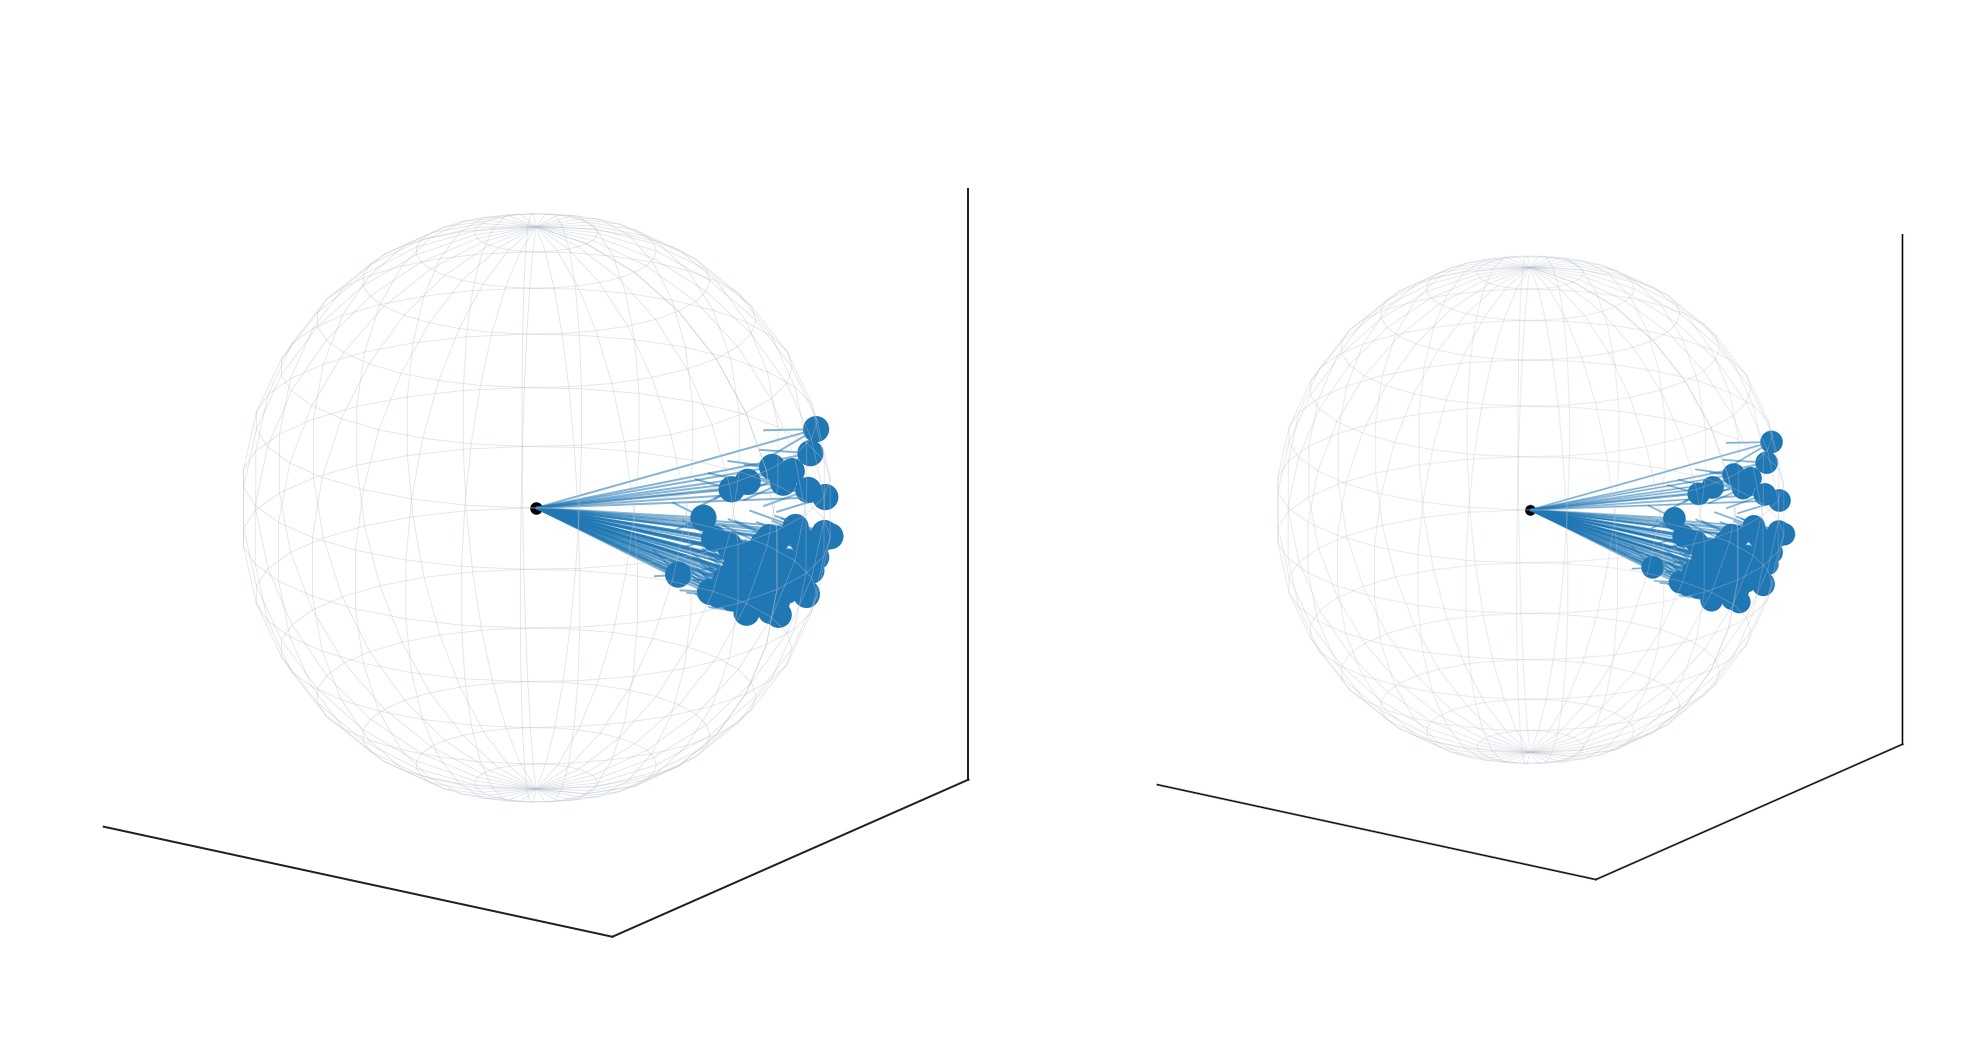

### Feature 33760 — `directed_ray` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

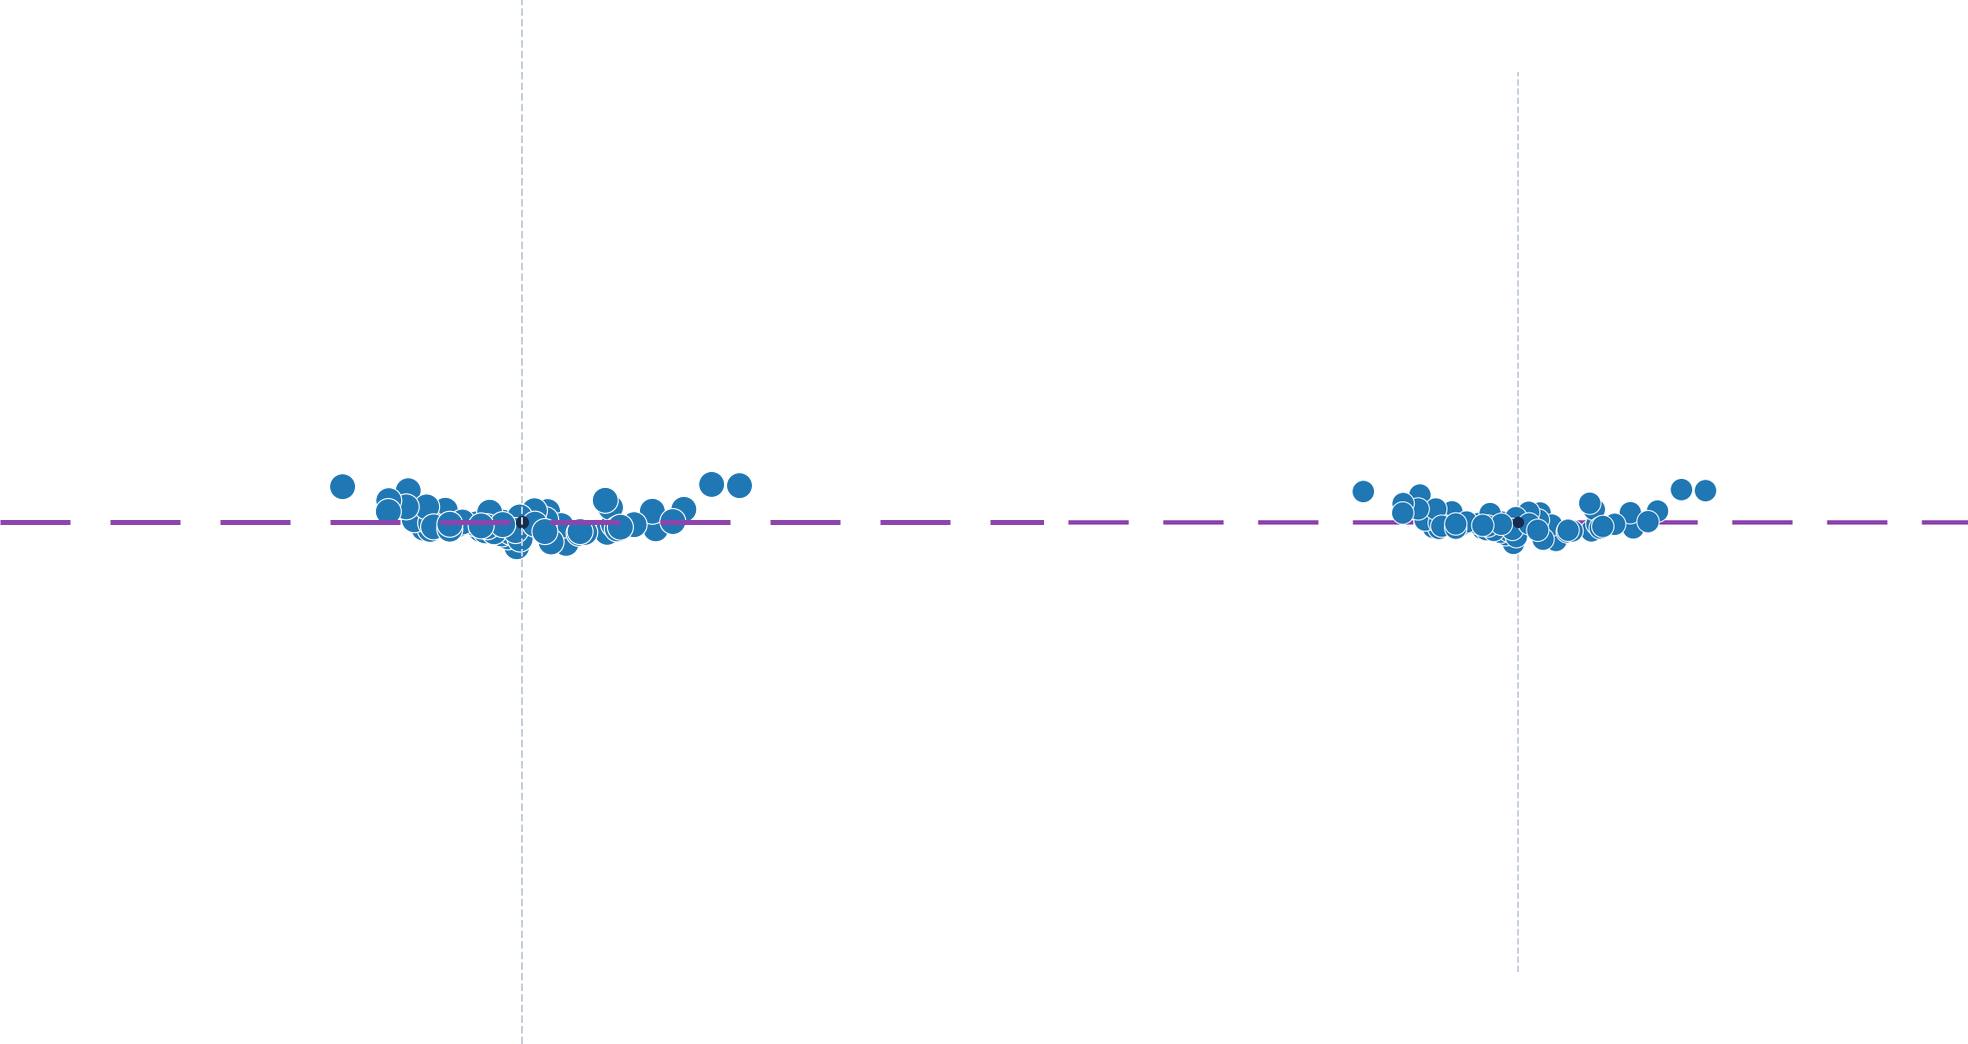

### Feature 14513 — `axis_or_antipodal` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

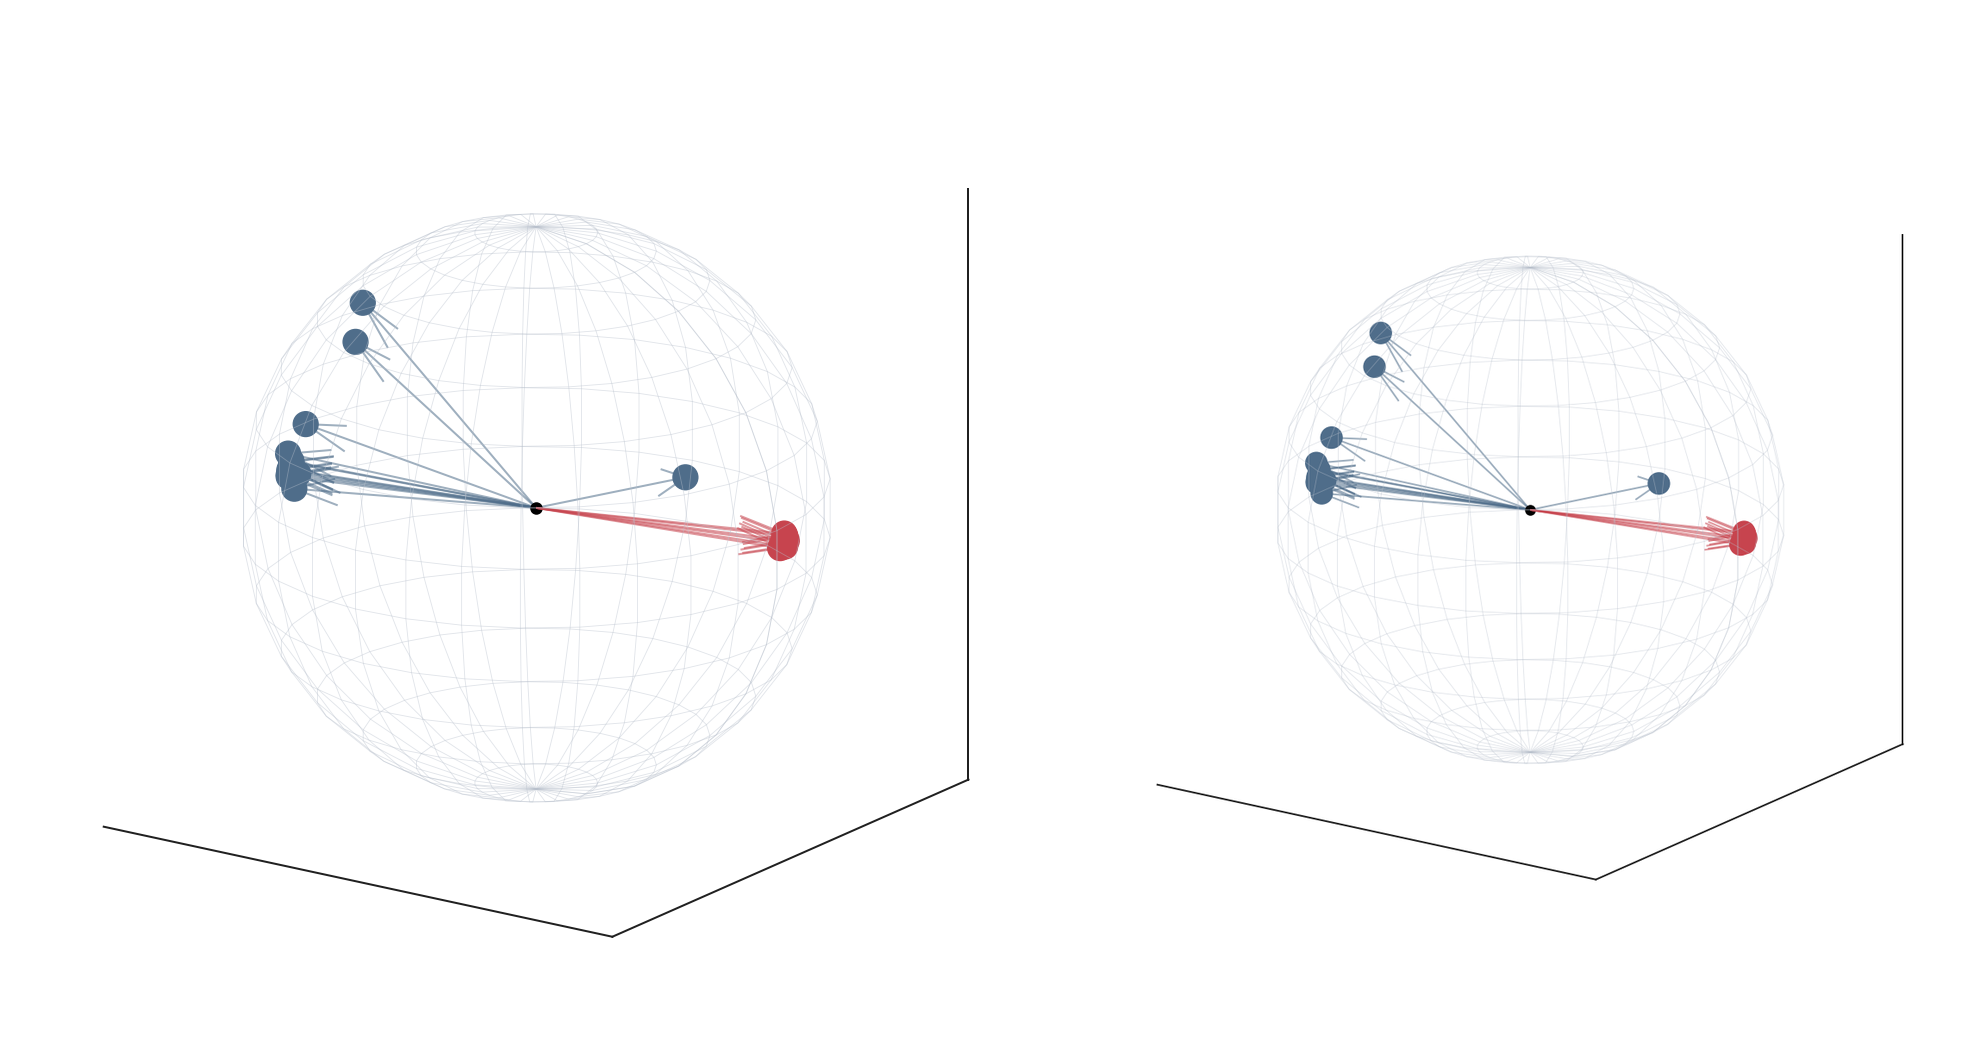

### Feature 14513 — `axis_or_antipodal` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

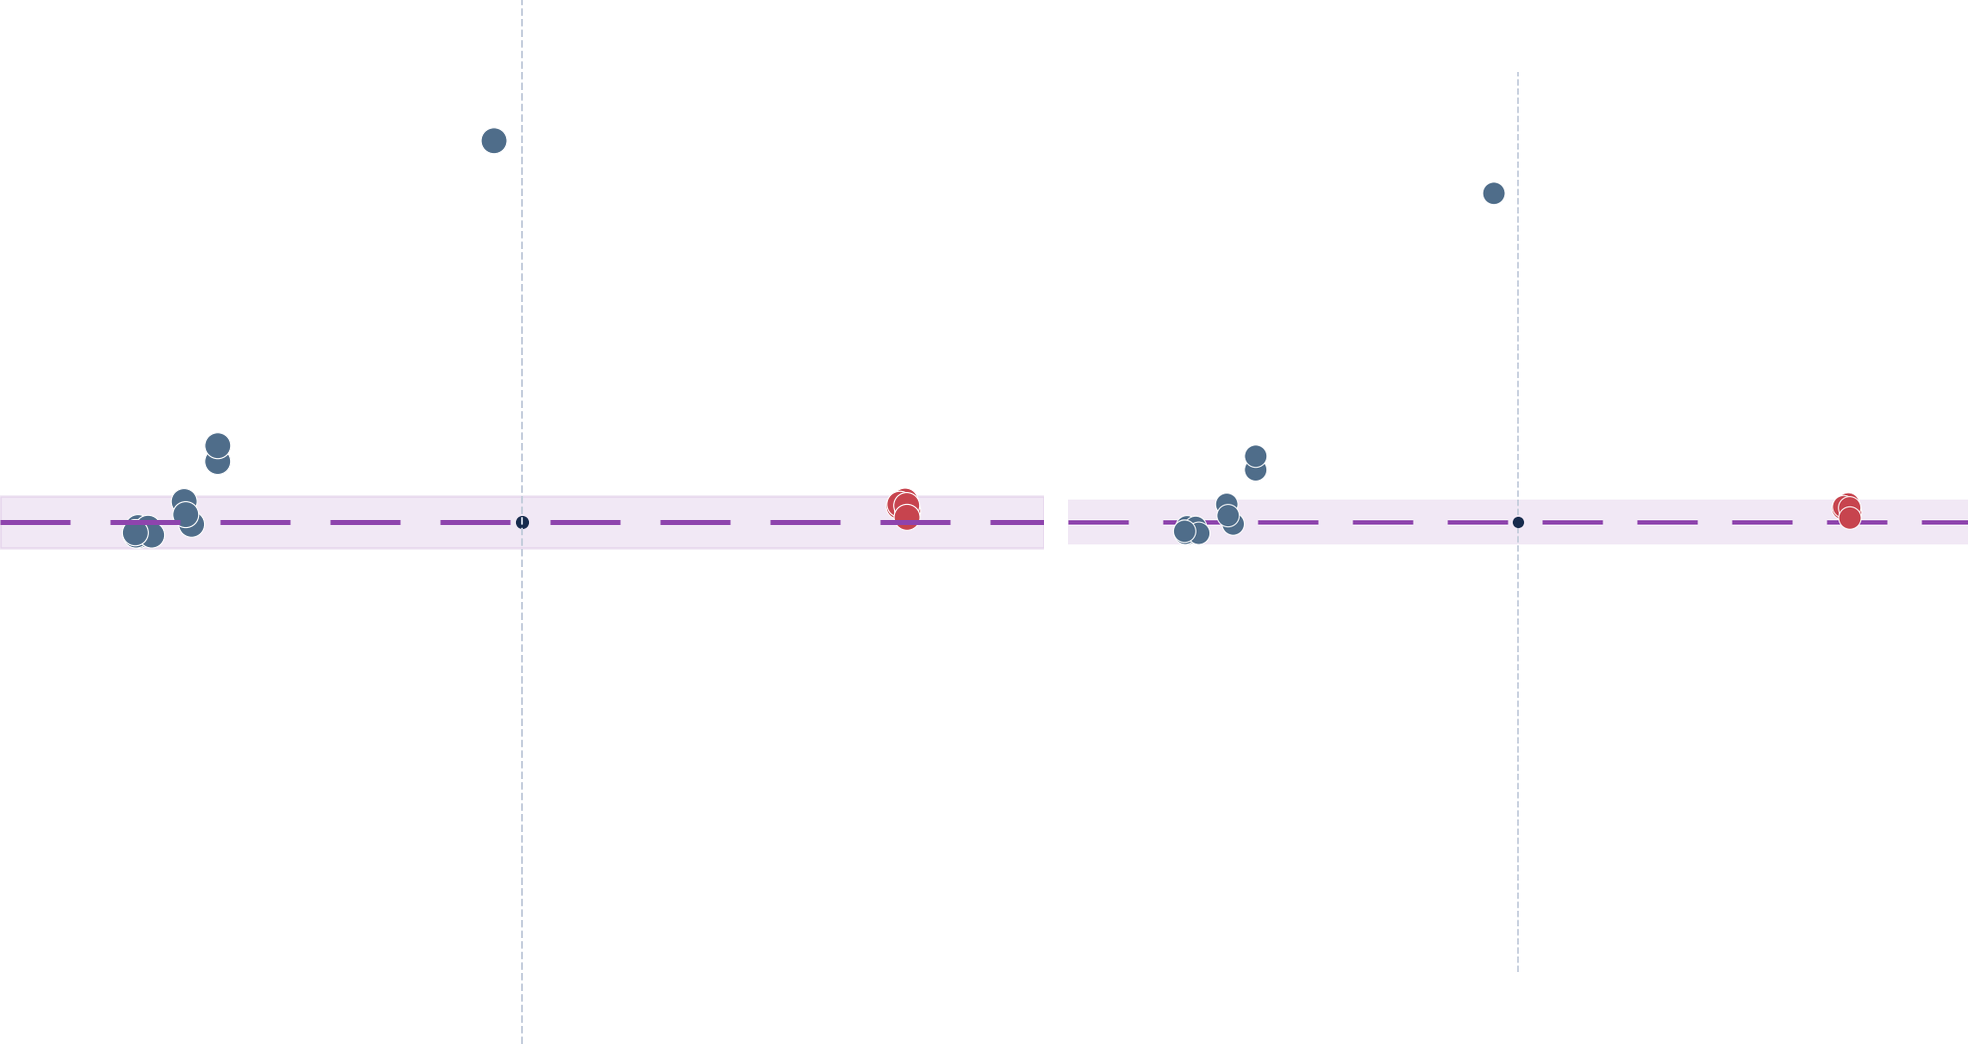

### Feature 54361 — `global_2D_directional_subspace` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

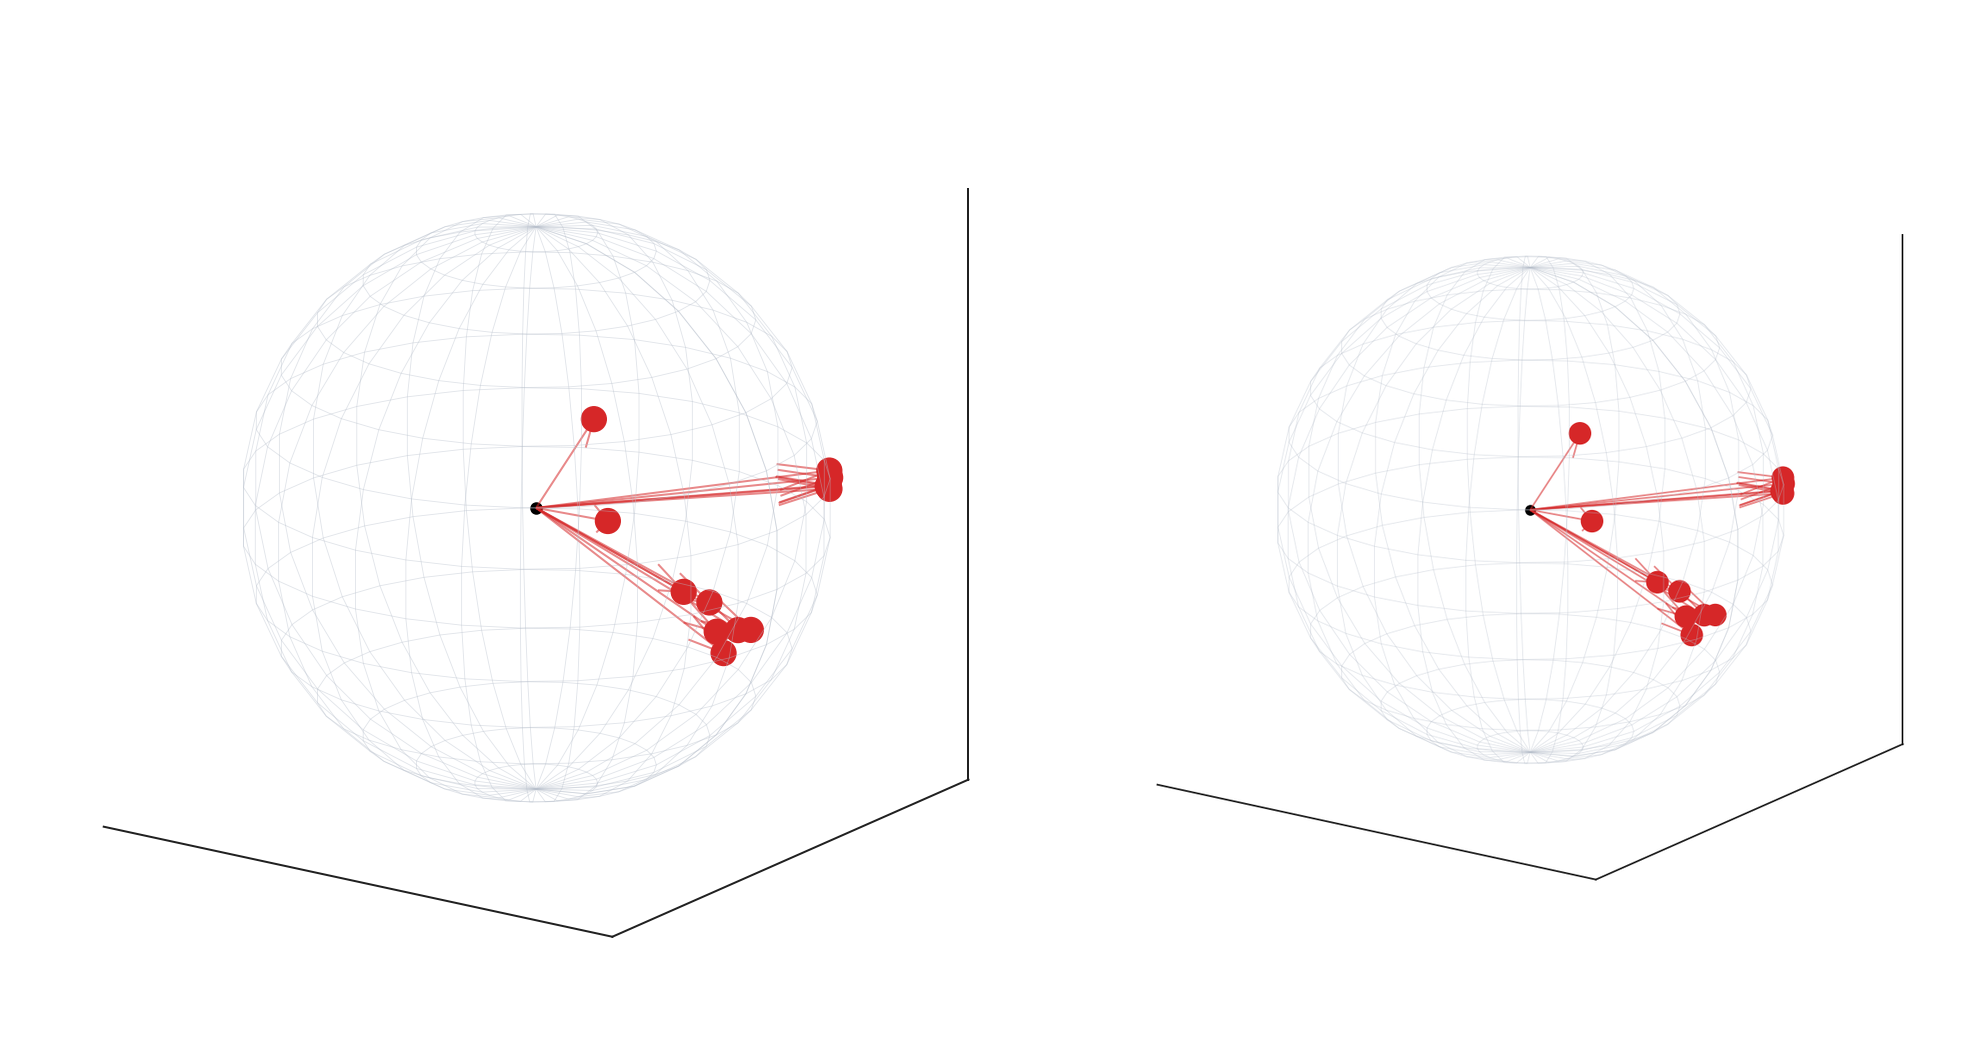

### Feature 54361 — `global_2D_directional_subspace` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

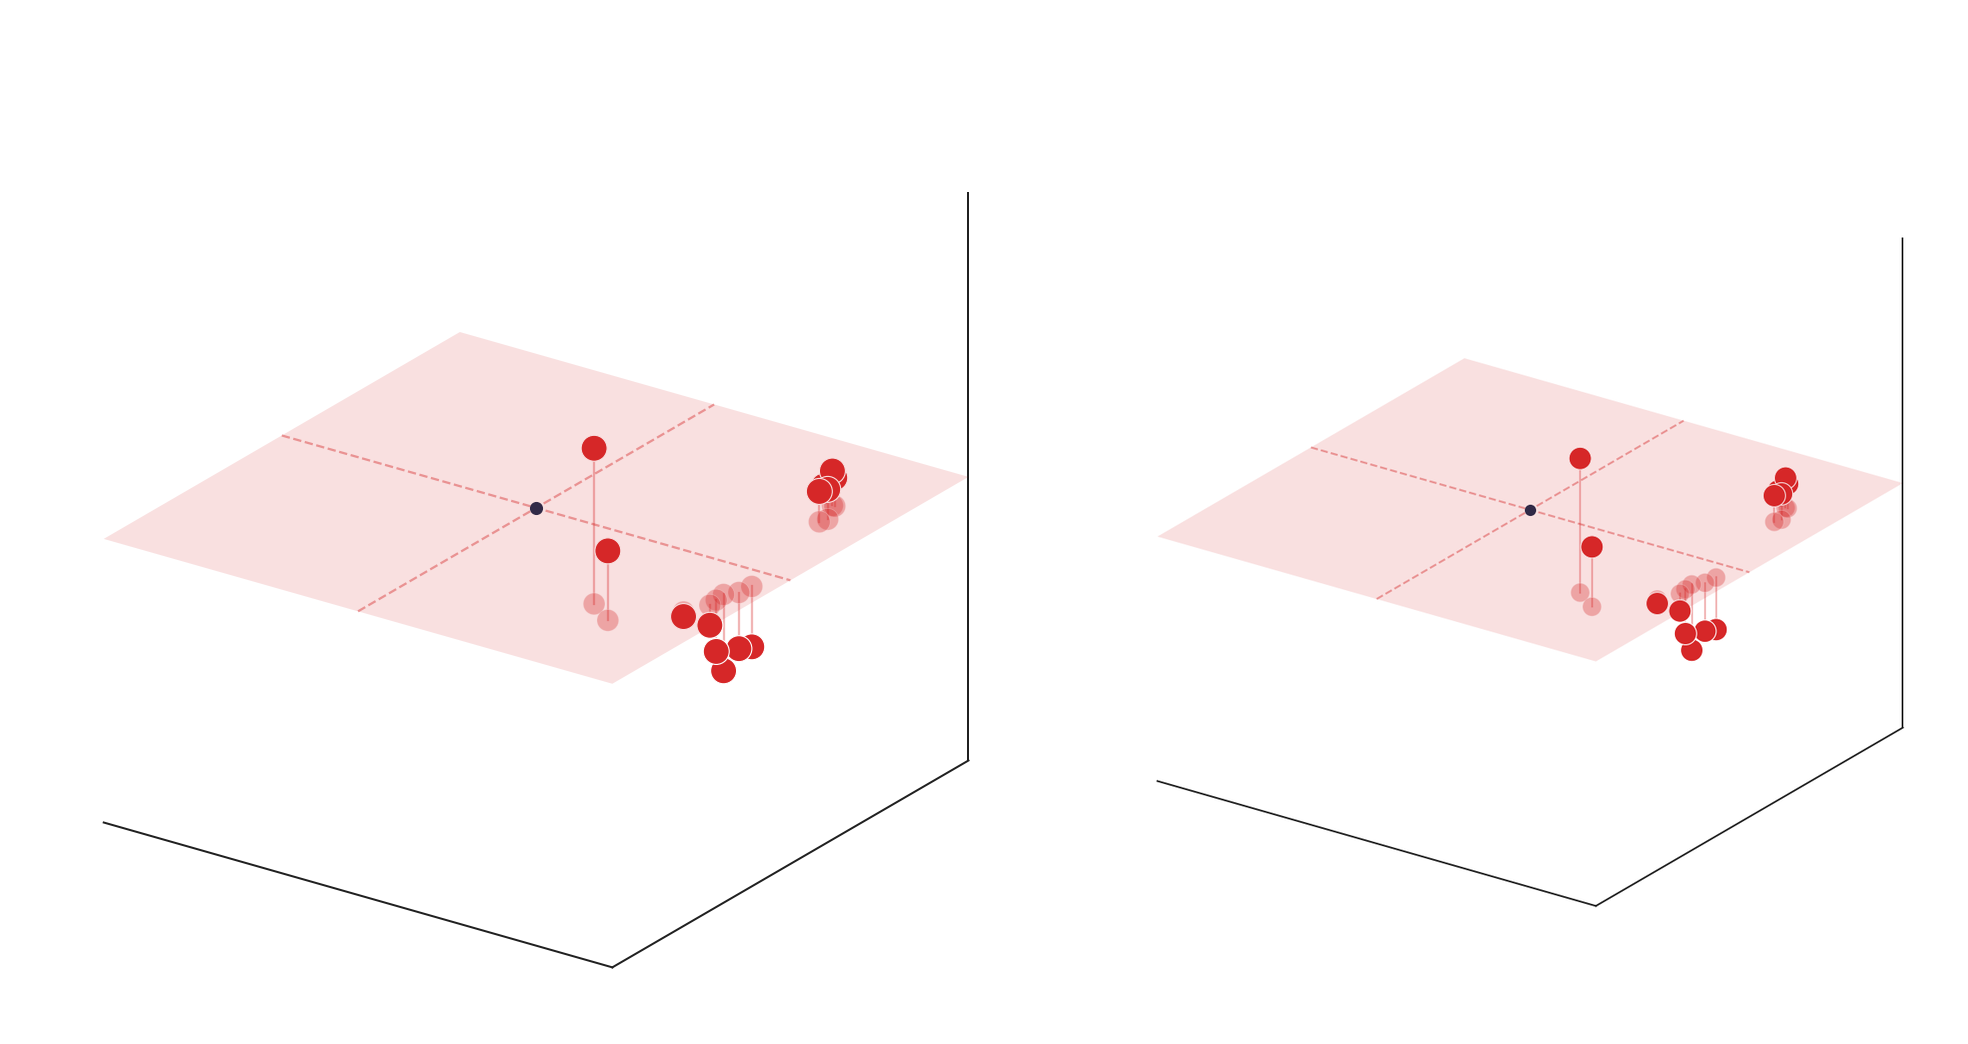

### Feature 32542 — `global_kD_directional_subspace` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

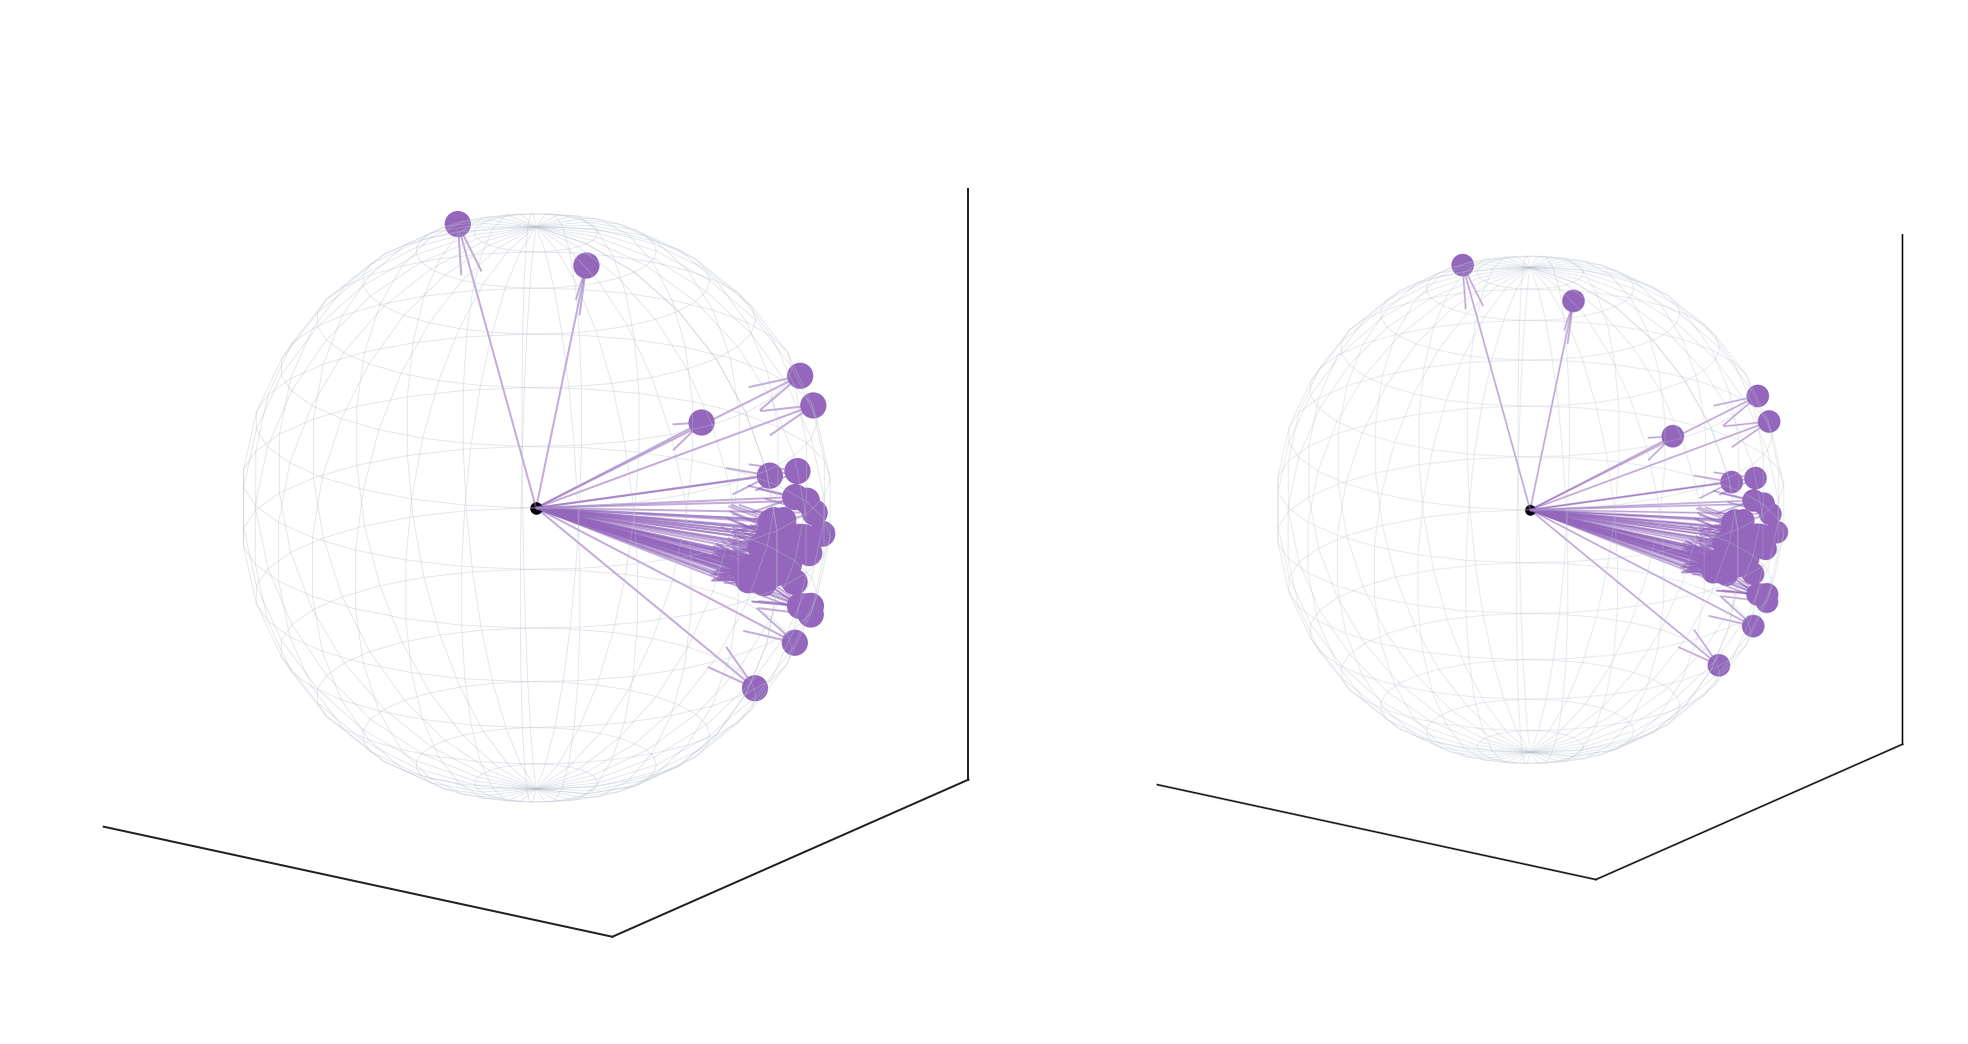

### Feature 32542 — `global_kD_directional_subspace` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

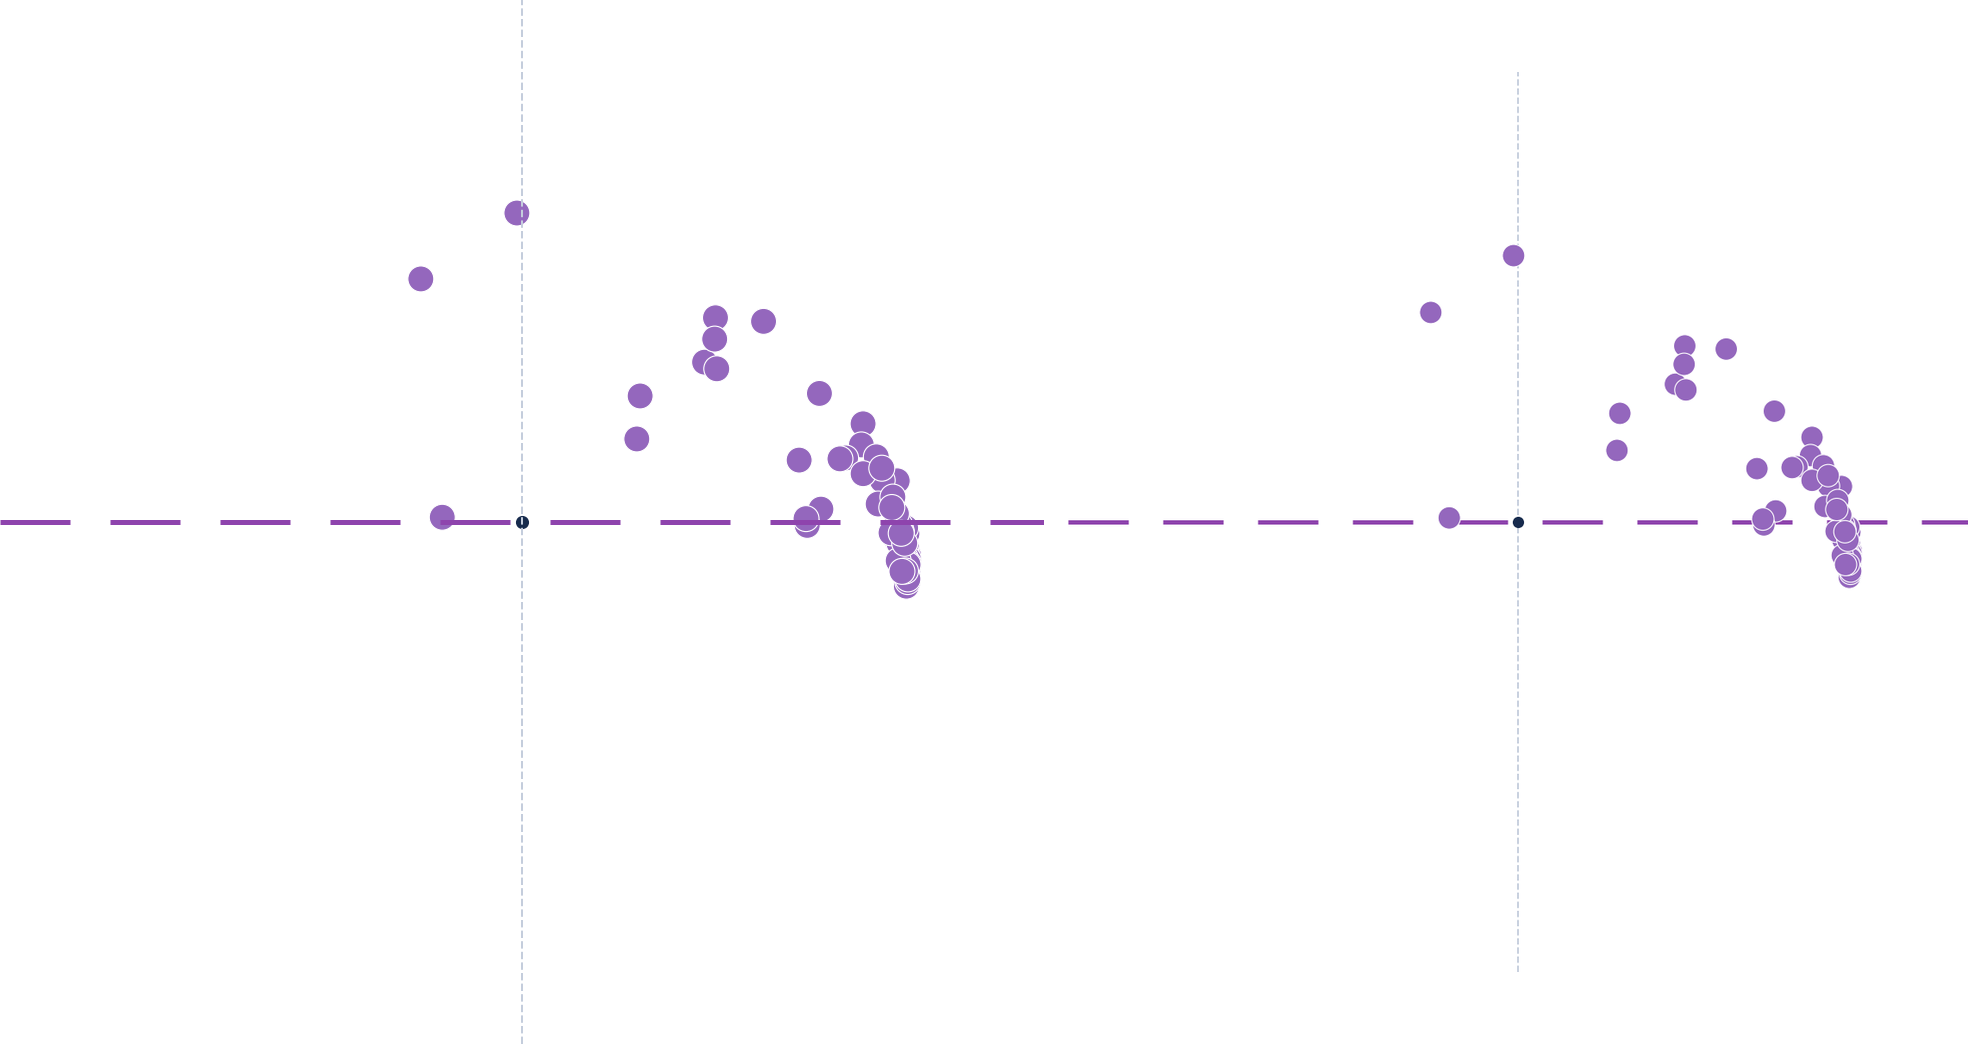

### Feature 59154 — `oneD_diffuse` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

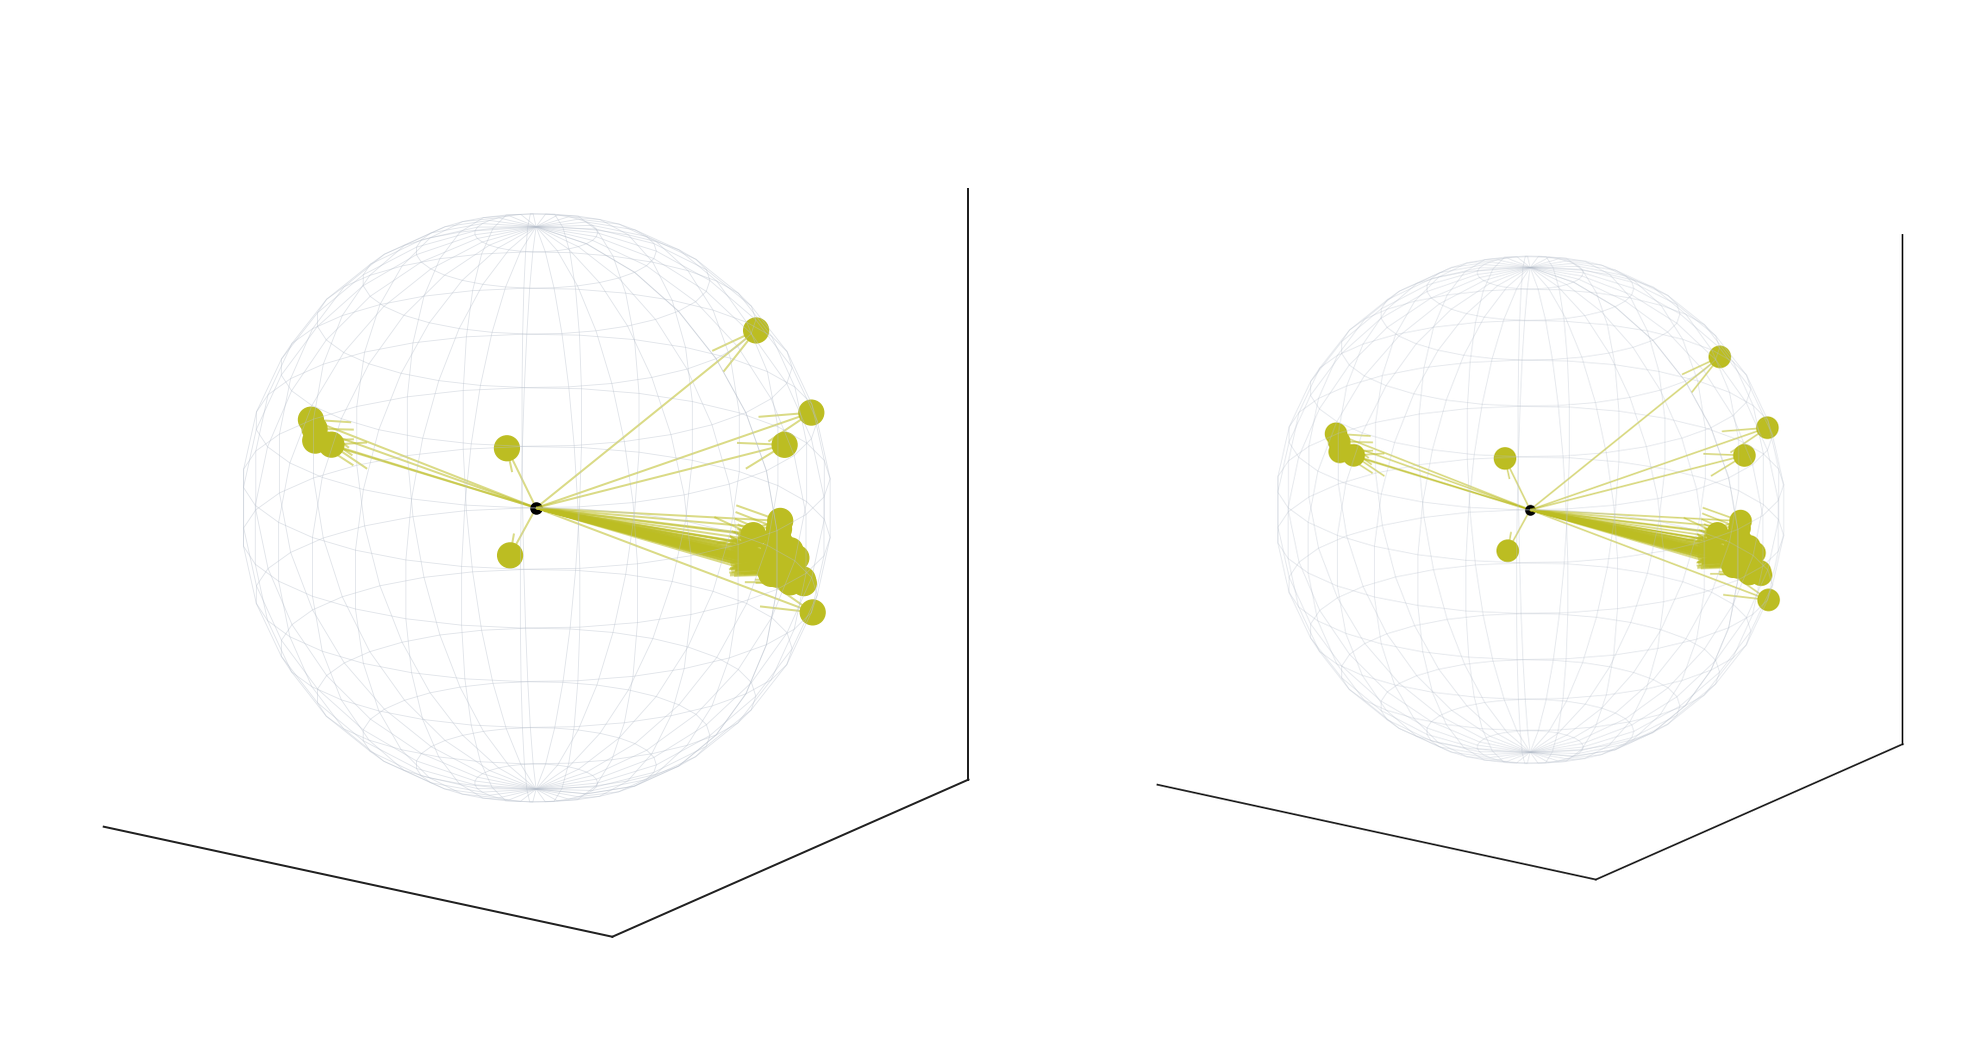

### Feature 59154 — `oneD_diffuse` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

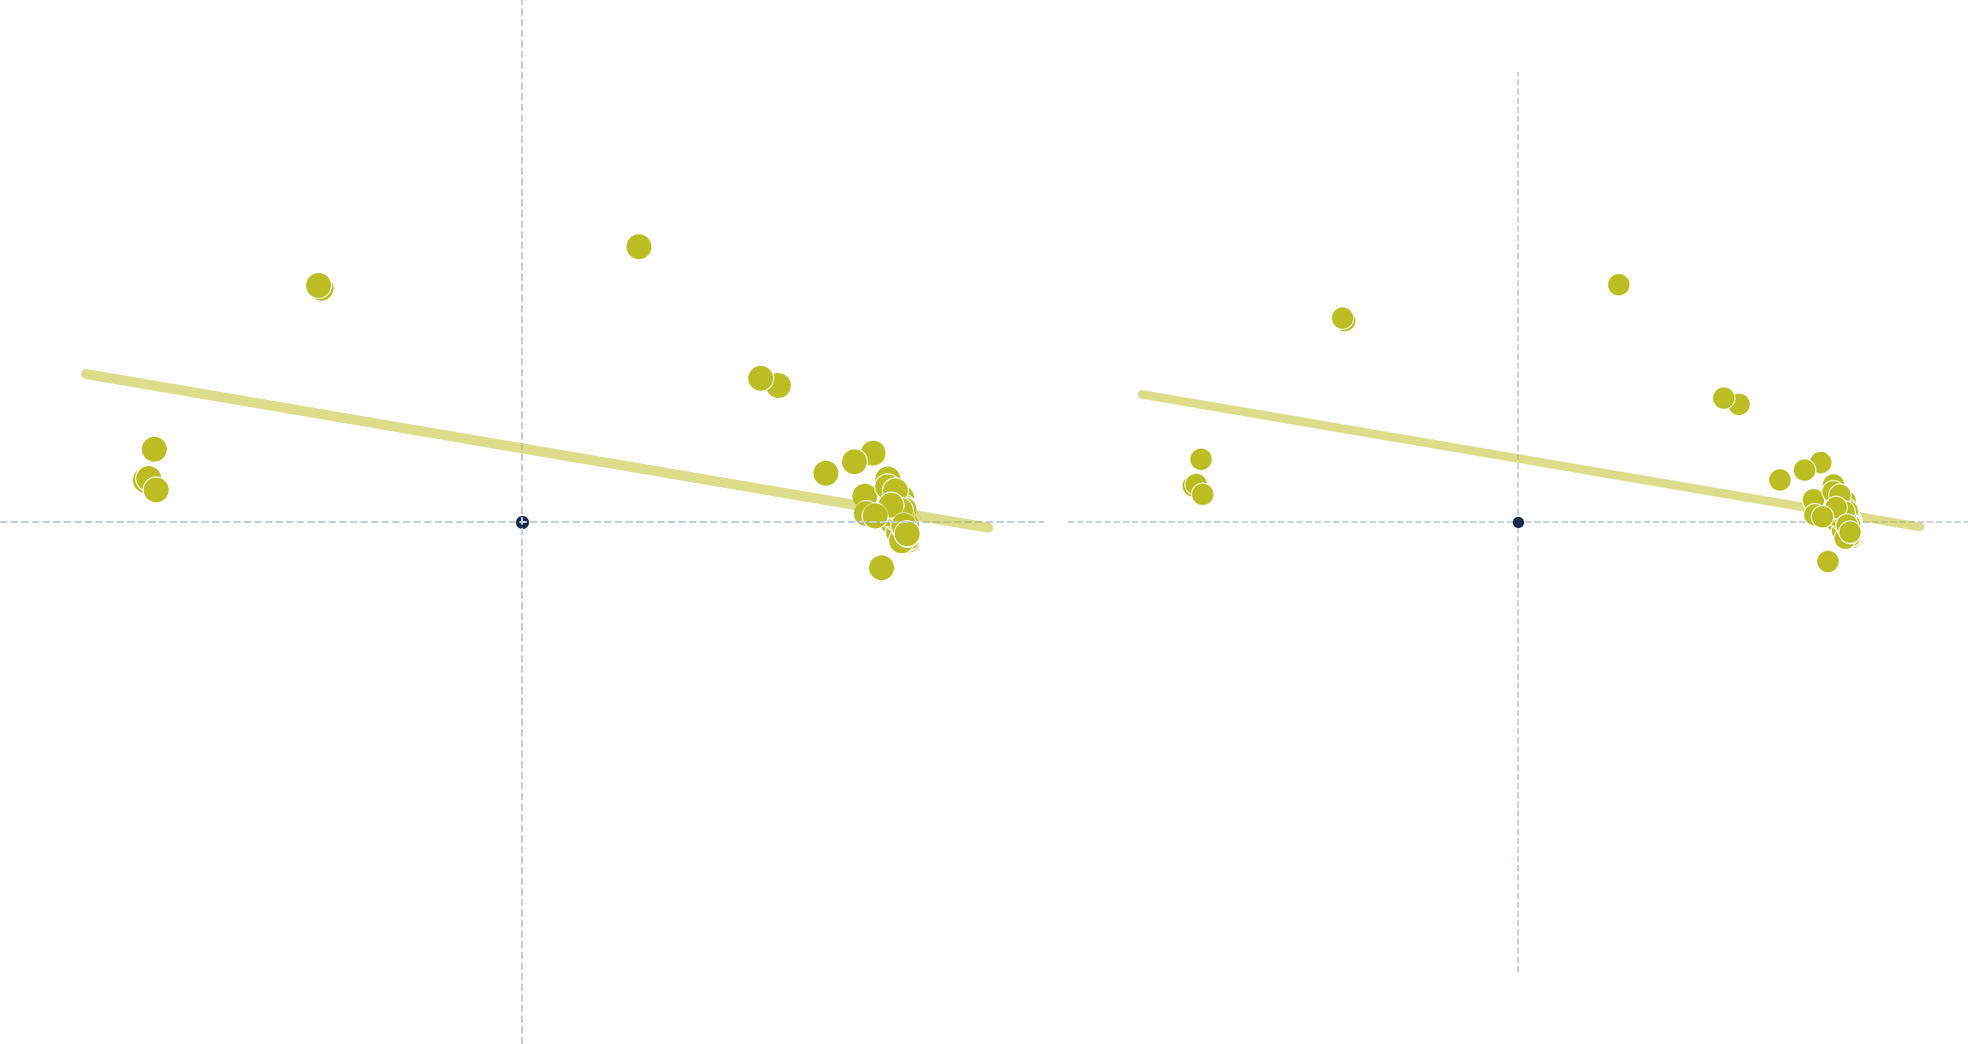

### Feature 19224 — `residual_lowD_k` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

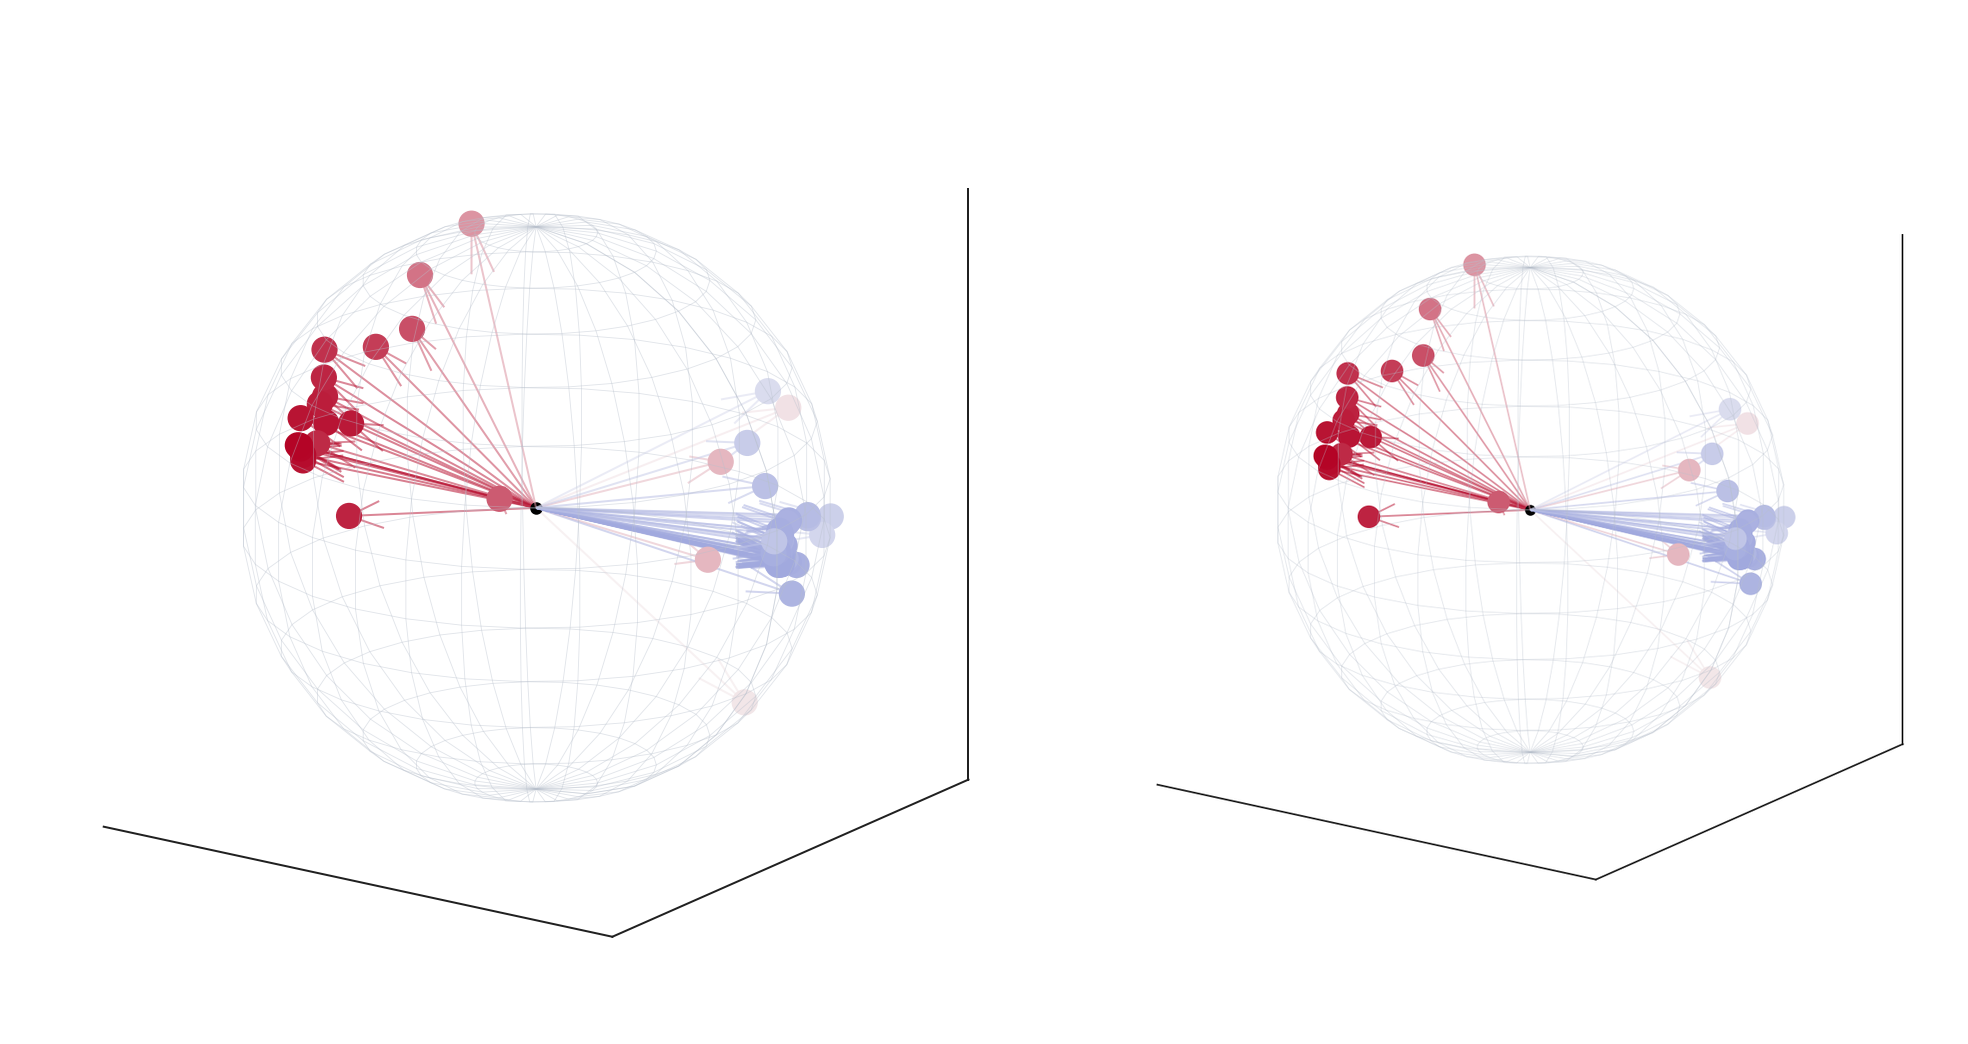

### Feature 19224 — `residual_lowD_k` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

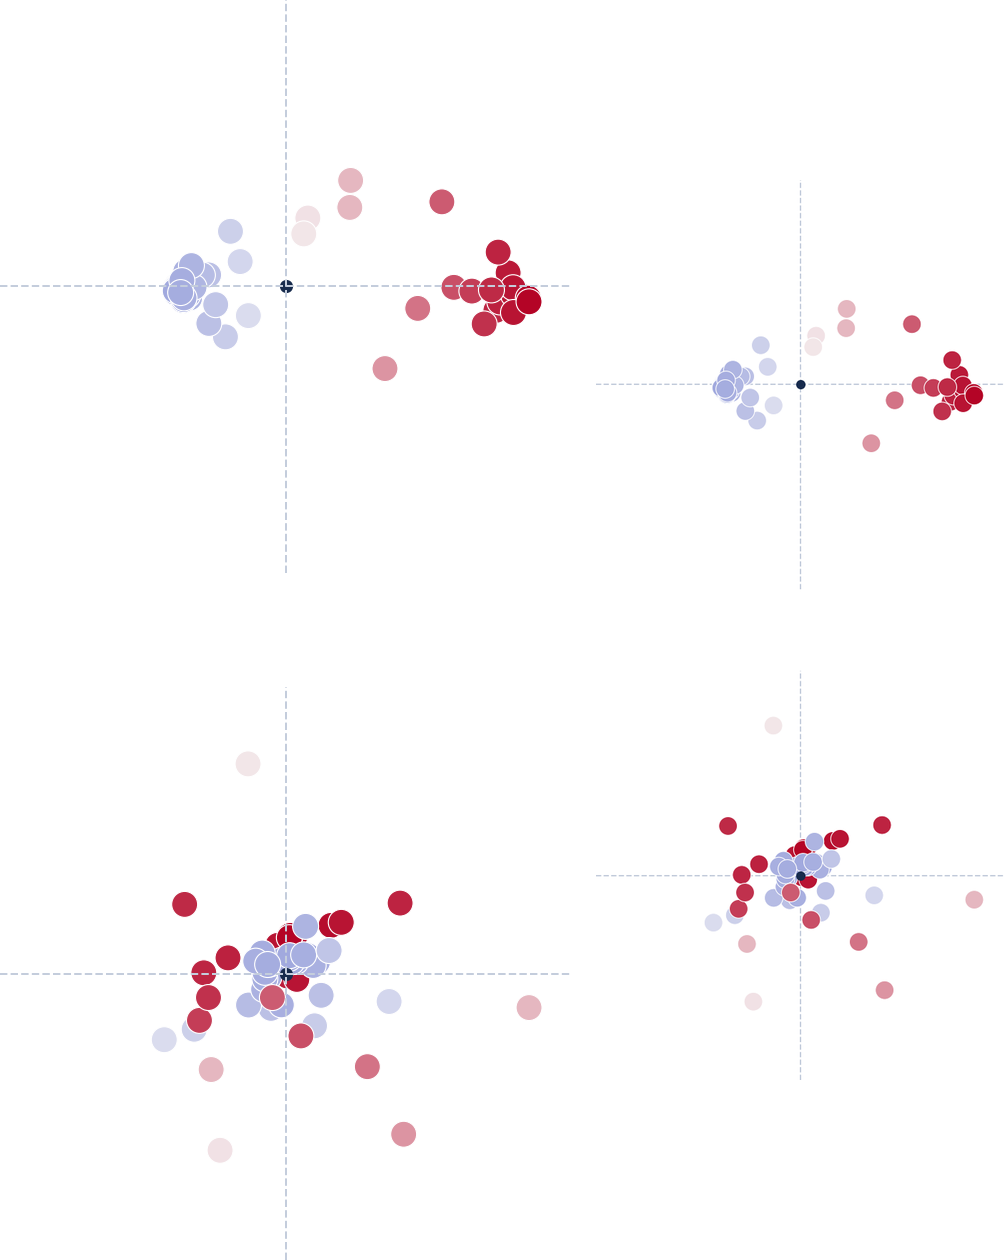

### Feature 34636 — `unresolved_high_dimensional_or_diffuse` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

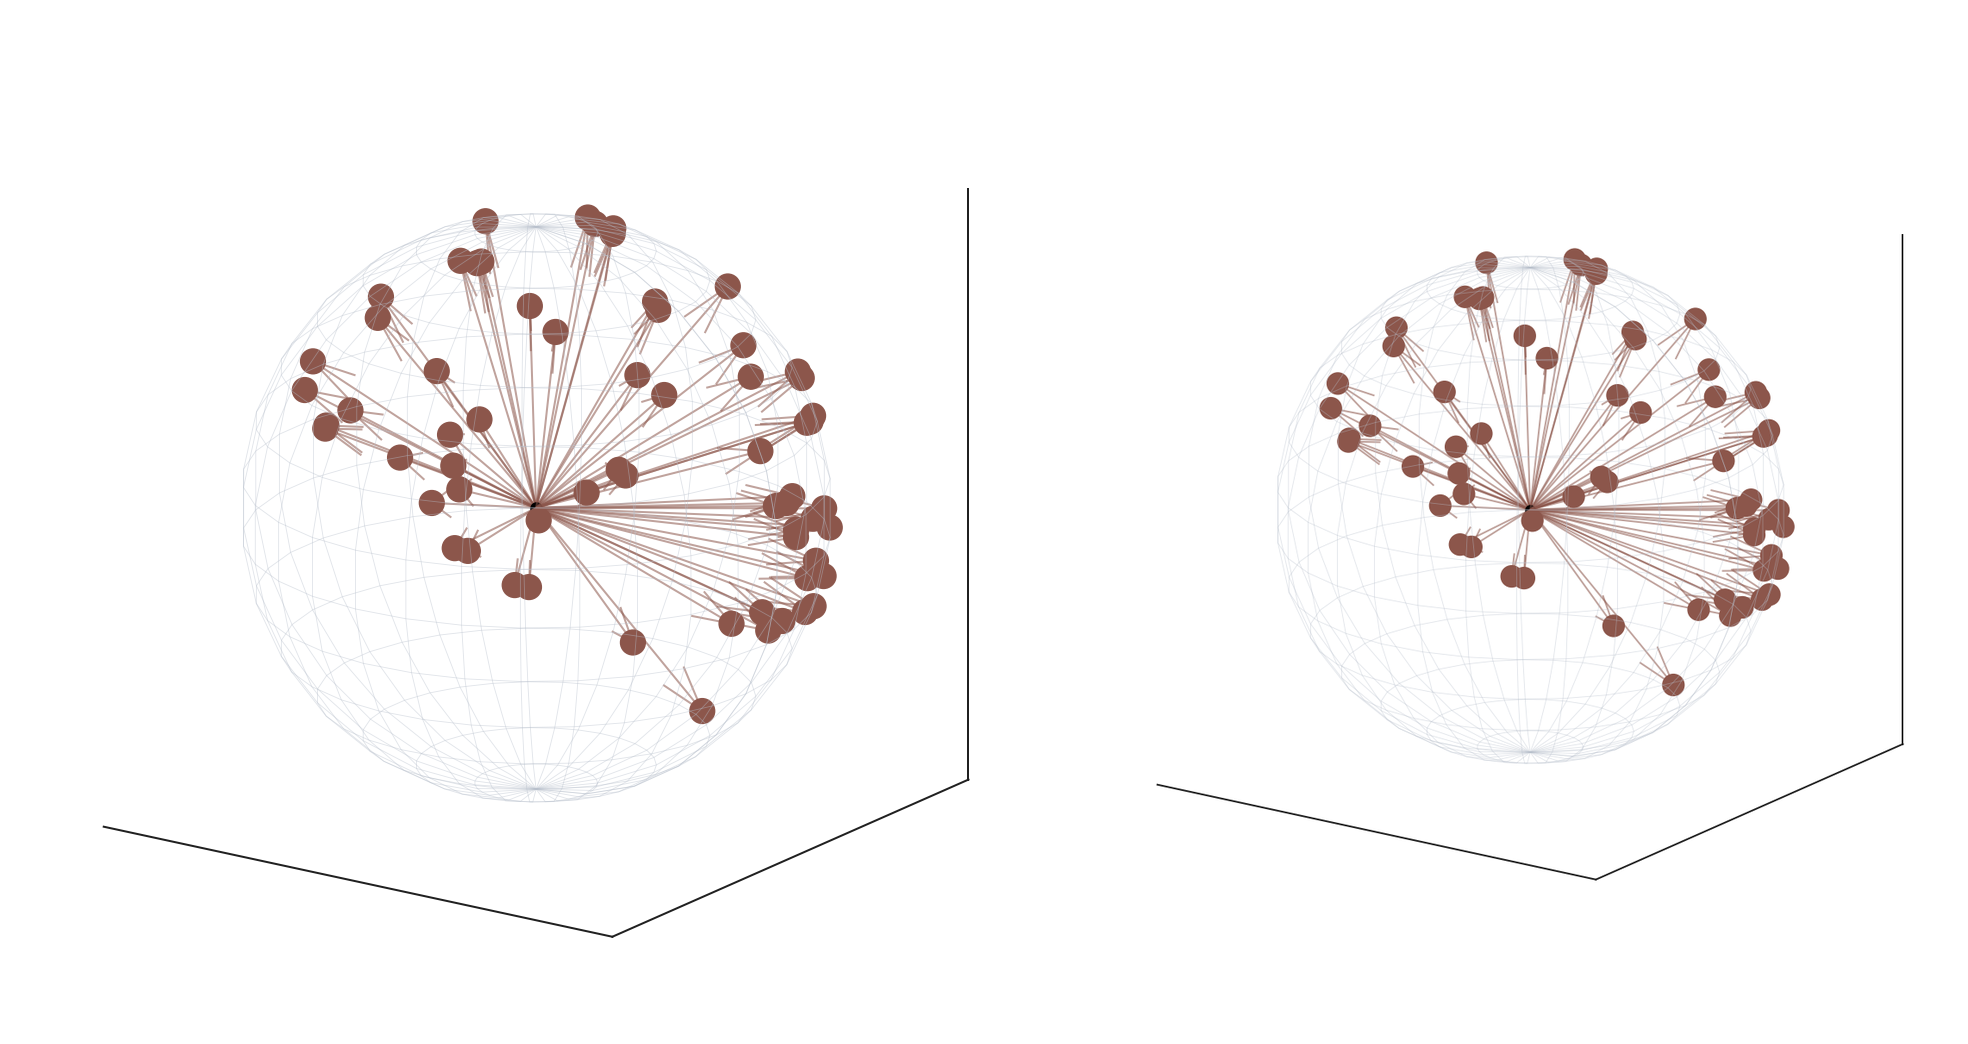

### Feature 34636 — `unresolved_high_dimensional_or_diffuse` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

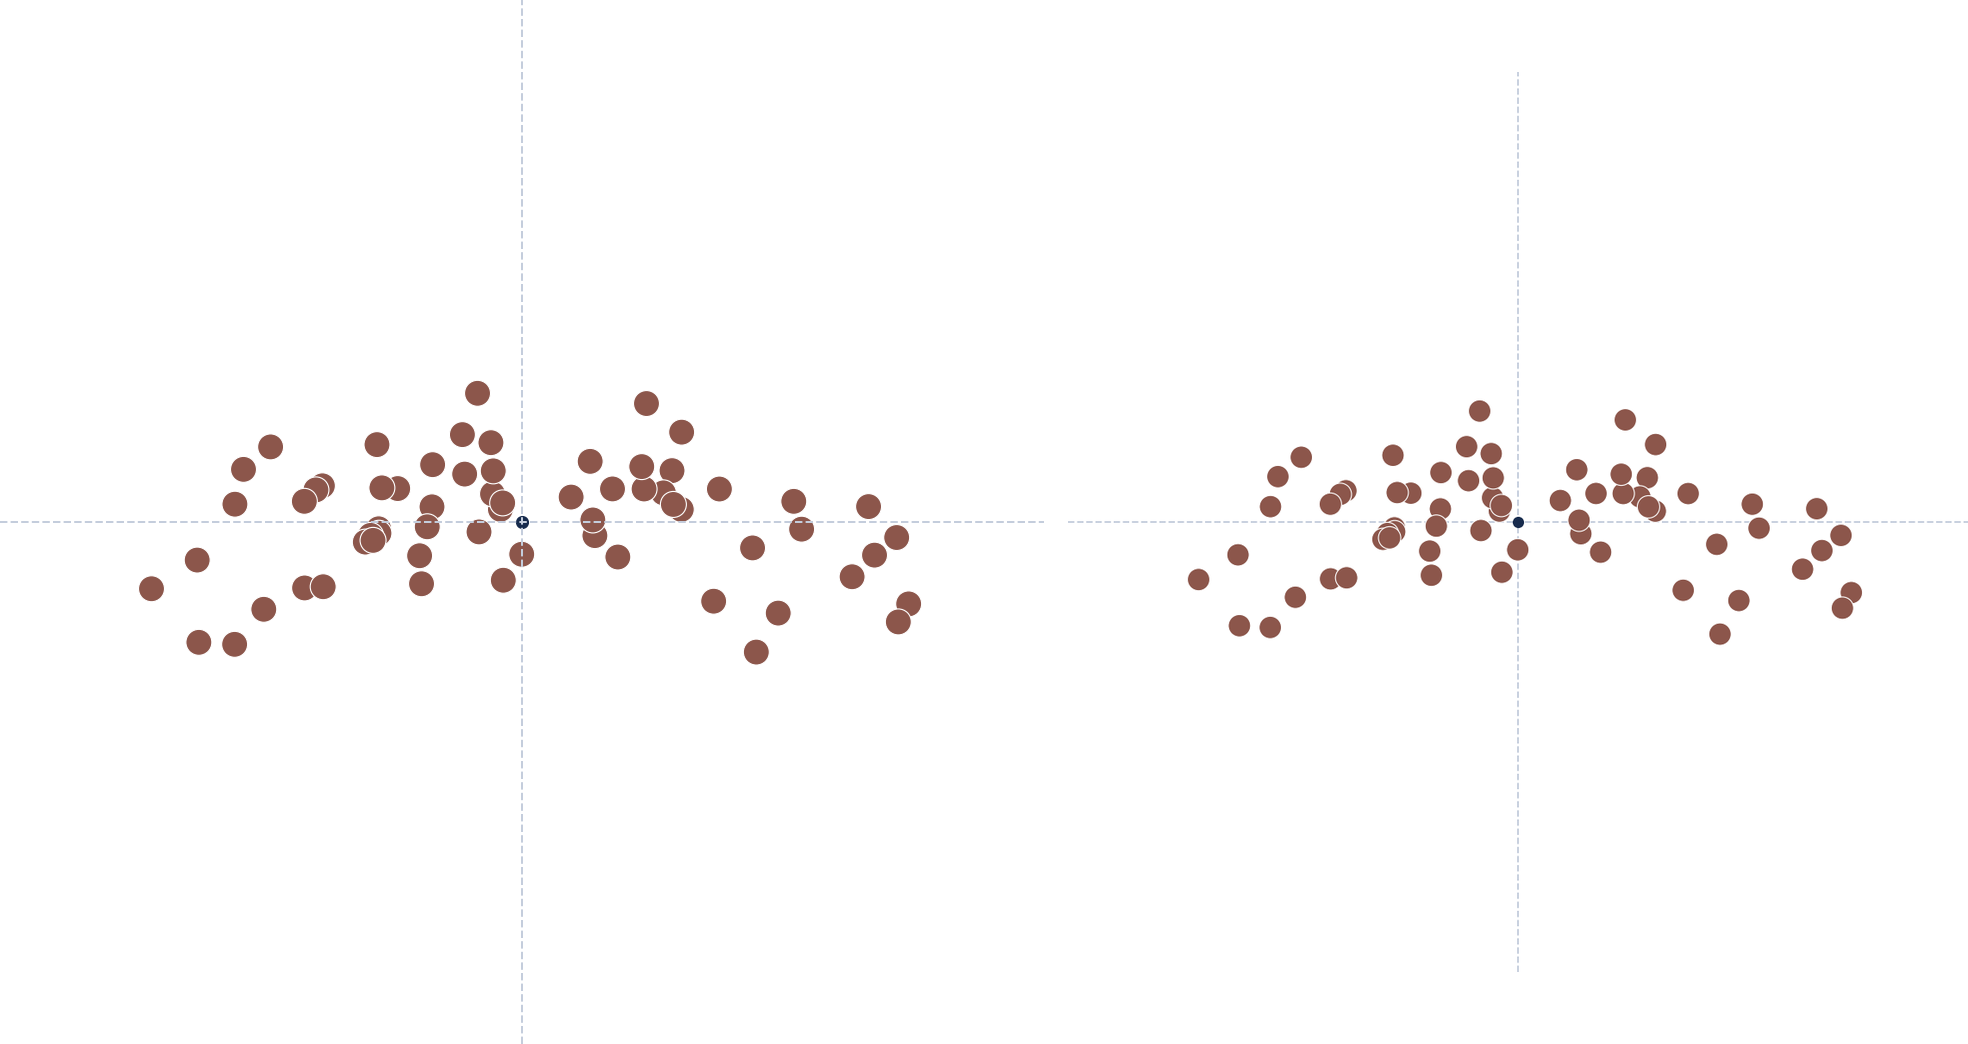

### Feature 1425 — `multi_mode_directional_geometry` — 3D sphere

**Left:** recomputed here · **Right:** original FEGA

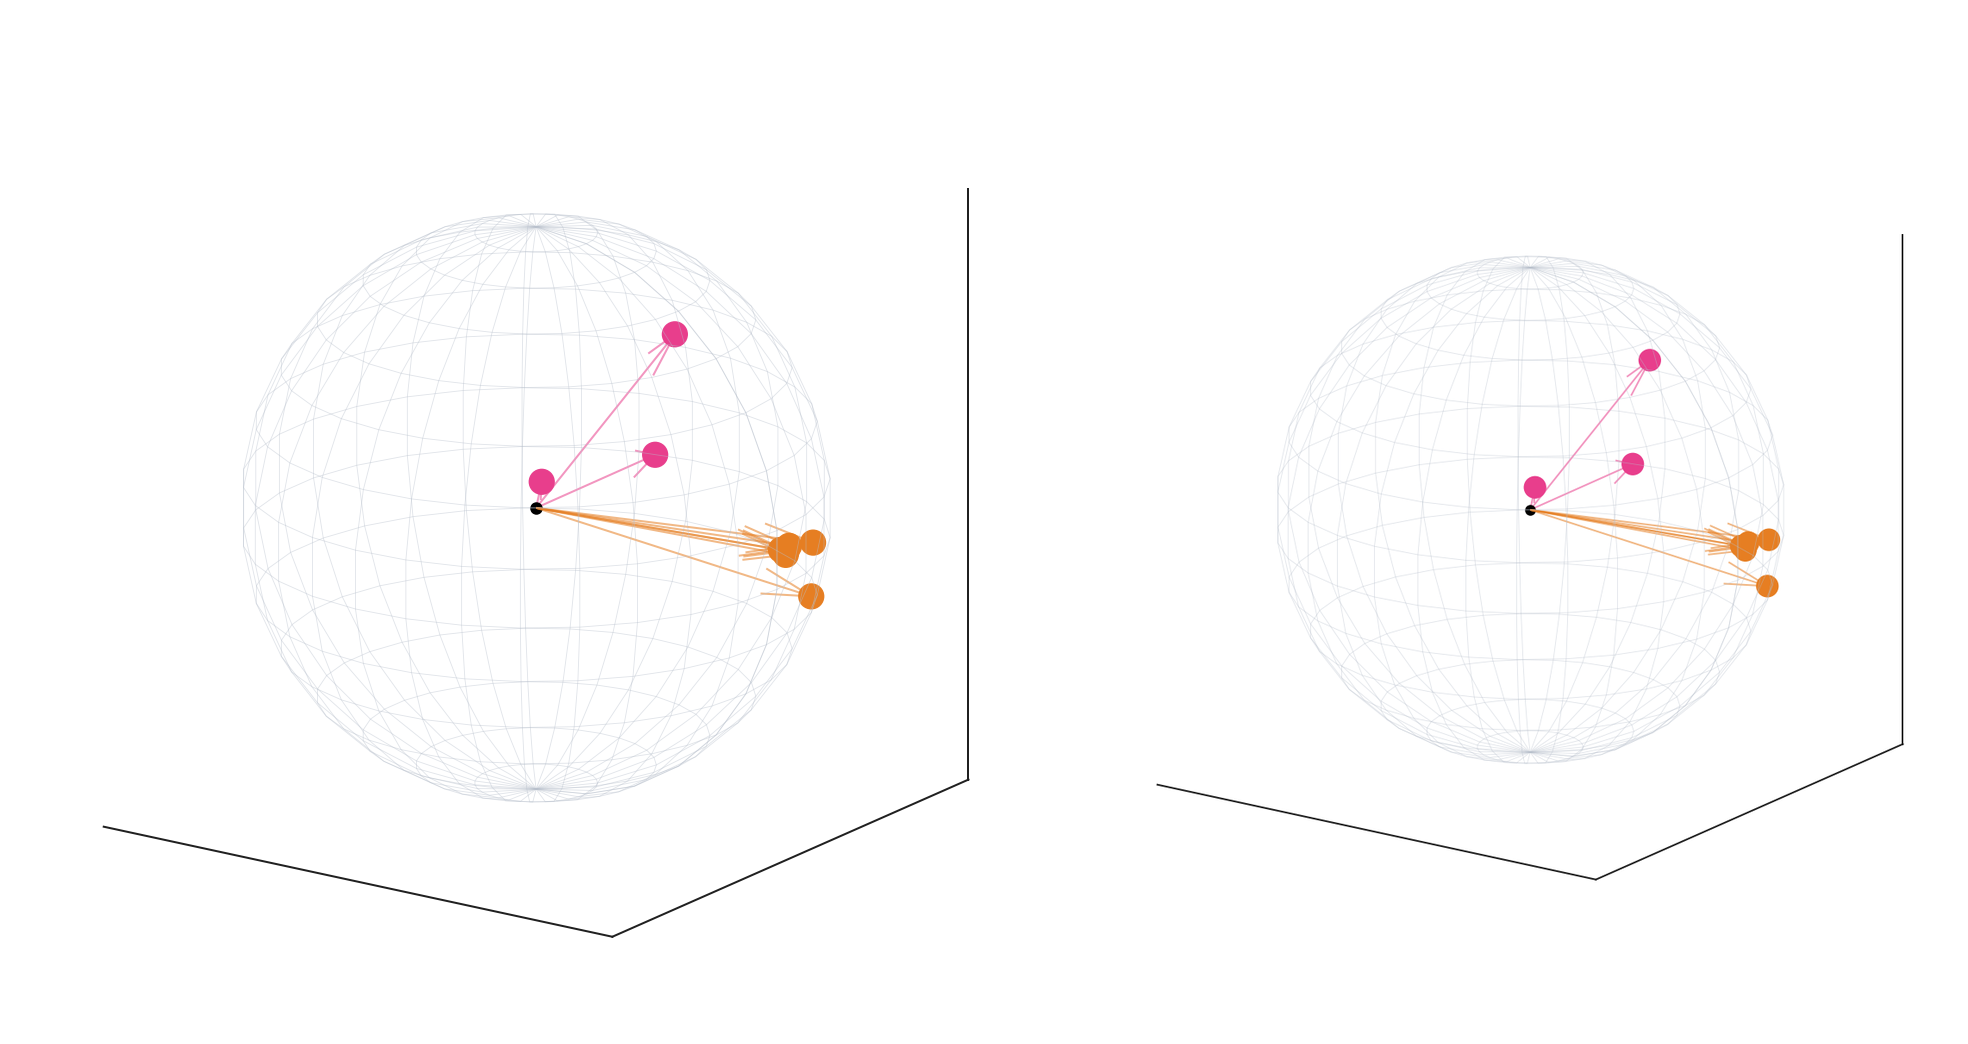

### Feature 1425 — `multi_mode_directional_geometry` — 2D projection

**Left:** recomputed here · **Right:** original FEGA

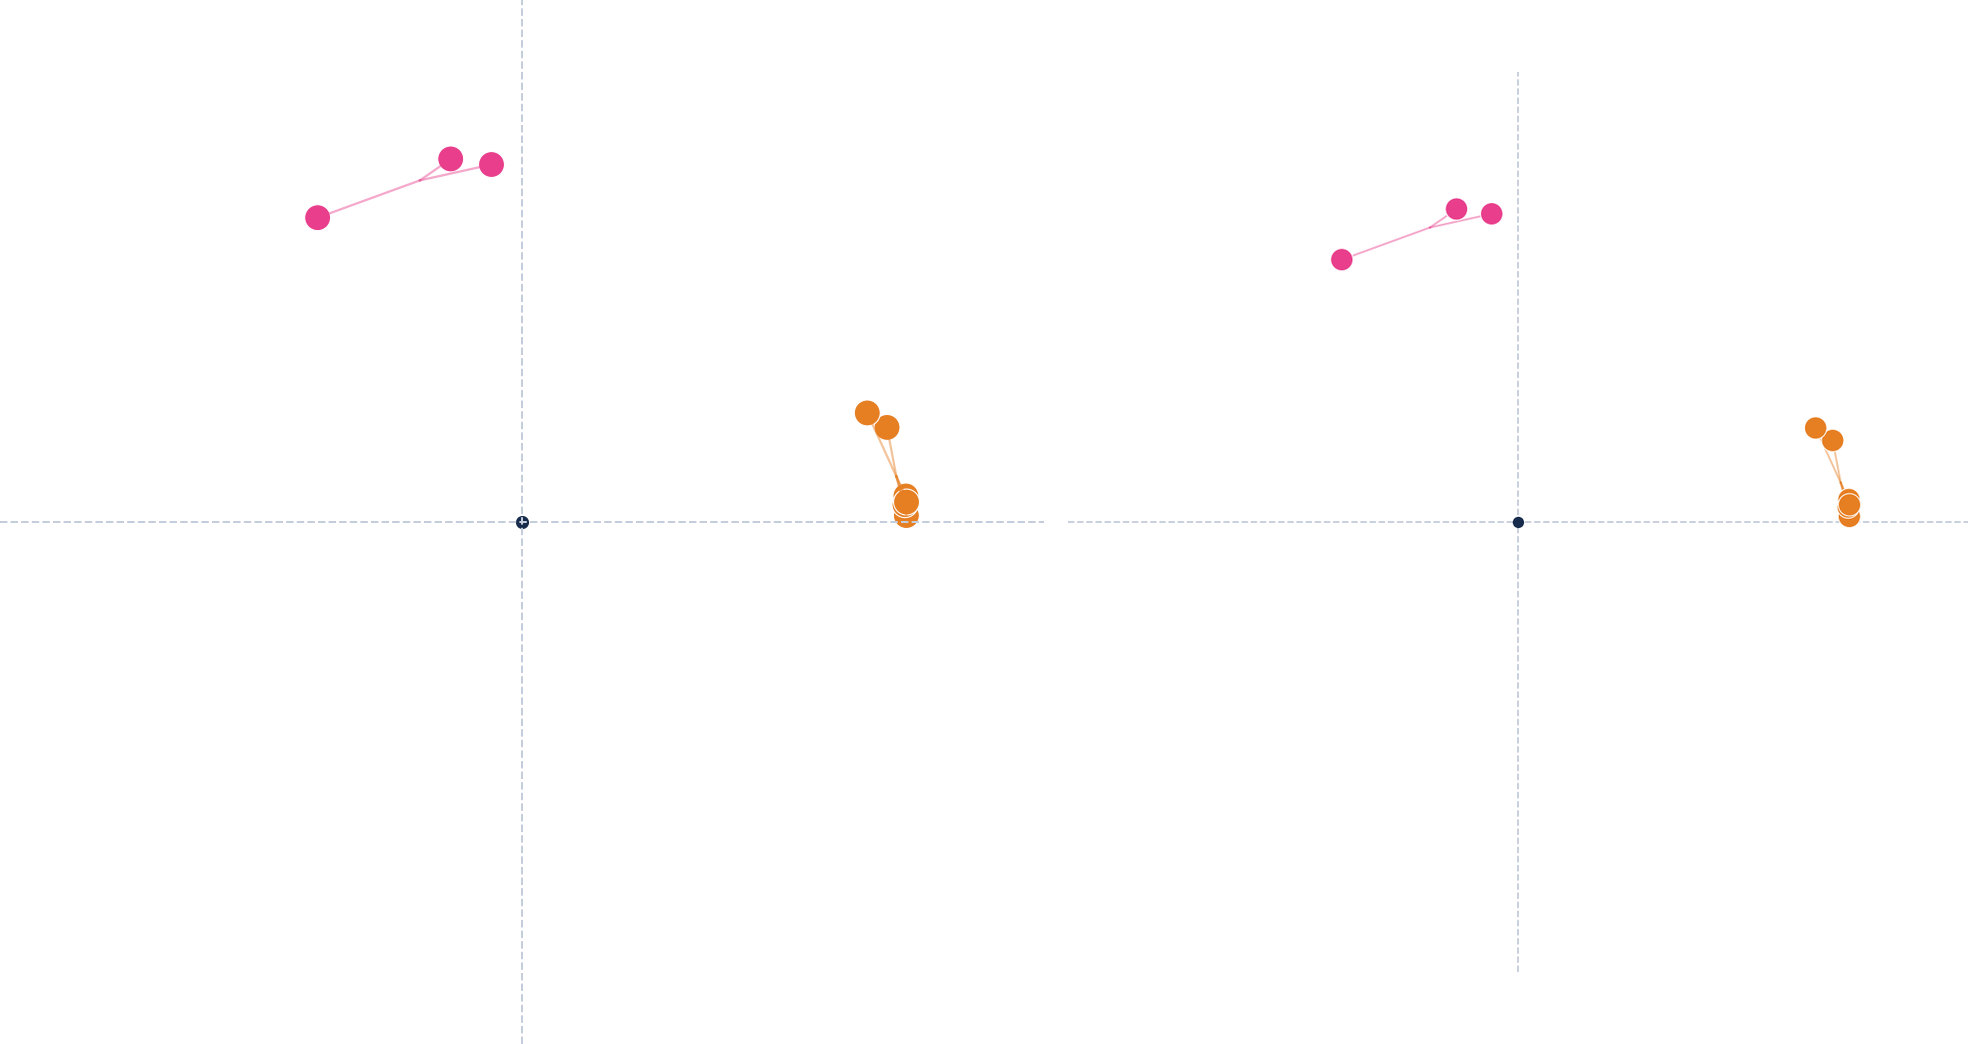

### Result

All eight examples recover the original geometry label, representative measurements, directional-clustering result, and stability decision. The 16 newly generated visualizations also reproduce the point and group structure of the original FEGA figures.

In [18]:
from IPython.display import Image

comparison_dir = tempfile.TemporaryDirectory(prefix="fega-comparisons-")

for row in comparison_rows:
    feature_id = row["feature_id"]
    family = row["family"]
    expected = expected_features[feature_id]
    captures = cached_results[fega_keys.VISUALIZATION].captures[feature_id]

    for figure_key, filename, title in (
        ("sphere_surface", "sphere_surface.png", "3D sphere"),
        ("projection_2d", "projection_2d.png", "2D projection"),
    ):
        capture = captures[figure_key]
        expected_capture = expected["render_inputs"][figure_key]

        # Compare the plotted geometry without requiring the same orientation.
        np.testing.assert_allclose(
            pairwise_squared_distances(capture.coordinates),
            pairwise_squared_distances(expected_capture["coordinates"]),
            **RENDERER_INVARIANT_TOLERANCE,
            err_msg=f"feature {feature_id}: {title}",
        )

        # Compare directional groups without depending on their numeric labels.
        expected_assignments = expected_capture["kwargs"].get("mode_assignments")
        if expected_assignments is None:
            assert capture.assignments is None
        else:
            assert capture.assignments is not None
            np.testing.assert_array_equal(
                assignment_partition(capture.assignments),
                assignment_partition(expected_assignments),
            )

        fresh_path = row["fresh_dir"] / filename
        source_path = source_figure_root / family / filename
        pair_path = Path(comparison_dir.name) / f"f{feature_id}_{filename}"
        compose_pair(fresh_path, source_path, pair_path)

        display(
            Markdown(
                f"### Feature {feature_id} — `{family}` — {title}\n\n"
                "**Left:** recomputed here · **Right:** original FEGA"
            )
        )
        display(Image(filename=str(pair_path), width=300))

display(
    Markdown(
        "### Result\n\n"
        "All eight examples recover the original geometry label, representative "
        "measurements, directional-clustering result, and stability decision. "
        "The 16 newly generated visualizations also reproduce the point and "
        "group structure of the original FEGA figures."
    )
)

## 7. Recap and comparison with the paper

You used Murano to remove SAE feature `33760` from 64 prompts and measure how that intervention changed the model. You then applied FEGA’s geometry analysis to eight examples from the original experiments, covering every reported geometry family.

For all eight examples, the recomputed geometry measurements, directional-clustering results, stability decisions, and final labels agree with the original FEGA results. The newly generated 3D sphere and 2D projection figures also preserve the same point and group structure.

| What | Original FEGA study | Here |
| --- | --- | --- |
| Feature effects | Collected across many models, SAEs, features, and datasets | Collected again for feature `33760` on 64 prompts |
| Geometry analysis | Applied to every eligible feature | Applied to eight original examples, one per geometry family |
| Classification | Reports eight possible geometry families | Recovers the original label for all eight examples |
| Visualization | Produces feature atlases and individual views | Recreates one 3D sphere and one 2D projection for each example |
| Aggregate findings | Measures how frequently each family occurs | Not repeated |

The live feature is processed in batches of eight. Changing the batch grouping can slightly change reduced-precision model activations and may therefore change its resulting geometry. Batch size eight should be kept when repeating the displayed live result.

The other eight examples begin from effect matrices produced by the original model interventions. Their geometry measurements, clustering, stability analysis, labels, and figures are recomputed here. This avoids repeating the paper’s expensive dataset construction, feature search, and model-wide sweeps while still exercising every FEGA geometry family.

Here we reproduce representative FEGA analyses, not the paper’s aggregate prevalence results or complete feature atlas.

## Citation

If you use this reproduction, cite the FEGA paper:

```bibtex
@misc{hoang2026sparseautoencoders,
  title         = {Sparse Autoencoders Encode Both Concepts and Functions:
                   The Downstream Geometry of Feature Effects},
  author        = {Phu Gia Hoang and Anwoy Chatterjee and
                   Tanmoy Chakraborty and Iryna Gurevych and
                   Subhabrata Dutta},
  year          = {2026},
  eprint        = {2607.24645},
  archivePrefix = {arXiv},
  primaryClass  = {cs.LG},
  url           = {https://arxiv.org/abs/2607.24645},
}
```

Original implementation and project page:

- <https://github.com/UKPLab/FEGA>
- <https://ukplab.github.io/FEGA/>